# Stage 03 - Kiến trúc Đa nhiệm (Dual-Space Multi-Task Learning: RGB + YCrCb + 3D Depth + FFT/LBP Noise)
## Cấu hình Hệ thống & Khởi tạo Môi trường

In [1]:
# === CELL 1: CÀI ĐẶT MÔI TRƯỜNG ===
%pip install --upgrade pip --quiet
%pip install torch==2.14.0 torchvision --index-url https://download.pytorch.org/whl/xpu --quiet
%pip install timm albumentations optuna scikit-learn seaborn tqdm --quiet
print("✅ Hoàn tất kiểm tra và cài đặt thư viện cho Stage 3!")

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
✅ Hoàn tất kiểm tra và cài đặt thư viện cho Stage 3!


In [2]:
# === CELL 2: IMPORT THƯ VIỆN & KHỞI TẠO XPU ===
import os
import io
import gc
import json
import time
import math
import random
import shutil
import warnings
from pathlib import Path
from collections import Counter, defaultdict
from concurrent.futures import ThreadPoolExecutor

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.models as tv_models

import optuna
import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve

# Tắt đa luồng nội bộ của OpenCV để tránh xung đột (deadlock) với PyTorch DataLoader workers
cv2.setNumThreads(0)
warnings.filterwarnings("ignore")

# --- Cố định Seed đảm bảo tính tái lập ---
SEED = 42
def seed_everything(seed: int = 42):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if hasattr(torch, "xpu") and torch.xpu.is_available():
        torch.xpu.manual_seed(seed)
        torch.xpu.manual_seed_all(seed)

seed_everything(SEED)

# --- Kiểm tra và cấu hình thiết bị Intel XPU ---
has_xpu = hasattr(torch, "xpu") and torch.xpu.is_available()
if has_xpu:
    DEVICE = torch.device("xpu:0")
    n_xpu = torch.xpu.device_count()
    print(f"✅ Đã phát hiện {n_xpu} thiết bị XPU:")
    for i in range(n_xpu):
        try:
            props = torch.xpu.get_device_properties(i)
            total_mem_gb = getattr(props, "total_memory", 0) / (1024**3)
            print(f"   - xpu:{i} -> {torch.xpu.get_device_name(i)} (Bộ nhớ khả dụng: {total_mem_gb:.2f} GB)")
        except Exception:
            print(f"   - xpu:{i} -> {torch.xpu.get_device_name(i)}")
else:
    DEVICE = torch.device("cpu")
    print("⚠️ Không phát hiện XPU khả dụng -> Fallback về CPU.")

# --- Bật Mixed Precision (bfloat16) an toàn cho Intel XPU ---
USE_AMP = True if has_xpu else False
AUTOCAST_DEVICE_TYPE = "xpu" if has_xpu else "cpu"
AUTOCAST_DTYPE = torch.bfloat16

print(f"\nPyTorch version   : {torch.__version__}")
print(f"Thiết bị sử dụng  : {DEVICE}")
print(f"Mixed Precision   : {USE_AMP} (dtype={AUTOCAST_DTYPE})")

/home/dainguyen1506/Documents/face-anti-spoofing/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Đã phát hiện 1 thiết bị XPU:
   - xpu:0 -> Intel(R) Graphics (Bộ nhớ khả dụng: 13.24 GB)

PyTorch version   : 2.14.0+xpu
Thiết bị sử dụng  : xpu:0
Mixed Precision   : True (dtype=torch.bfloat16)


In [3]:
# === CELL 3: CẤU HÌNH HỆ THỐNG & THAM SỐ CHUNG (STAGE 3 - MULTI-TASK LEARNING) ===
PROJECT_ROOT   = Path("..").resolve()
DATASET_ROOT   = PROJECT_ROOT / "dataset"
MODELS_DIR     = PROJECT_ROOT / "models"
STAGE1_DIR     = PROJECT_ROOT / "checkpoint" / "stage1"
STAGE2_DIR     = PROJECT_ROOT / "checkpoint" / "stage2"
ARTIFACTS_DIR  = PROJECT_ROOT / "checkpoint" / "stage3"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

KAGGLE_DATASET_SLUG = "faber24/lcc-fasd"

# --- Cấu hình Ảnh, Bản đồ Phụ (Auxiliary Maps) & Nhãn ---
IMG_SIZE      = 192        # Độ phân giải ảnh RGB đầu vào (đồng nhất với Stage 1 & 2)
MAP_SIZE      = 24         # Độ phân giải bản đồ phụ 3D Depth & FFT/LBP Noise (tỷ lệ 1/8 của 192x192)
NUM_CLASSES   = 2          # 0 = spoof (giả mạo), 1 = real (người thật)
LABEL2IDX     = {"spoof": 0, "real": 1}
IDX2LABEL     = {v: k for k, v in LABEL2IDX.items()}

# --- Tối ưu hóa Phần cứng (Máy 16GB RAM + Intel Core Ultra / XPU) ---
NUM_WORKERS            = 4
CPU_THREADS            = 12
CACHE_TRAIN_VAL_IN_RAM = True
MAX_SAFE_CACHE_MB      = 3200
USE_CHANNELS_LAST      = has_xpu
PIN_MEMORY             = has_xpu

torch.set_num_threads(CPU_THREADS)

# --- Đường dẫn Checkpoints của Model 1 (Stage 1) & Model 2 (Stage 2) ---
MODEL1_BEST_CKPT_PATH   = MODELS_DIR / "model1_custom_cnn_best.pt"
MODEL2_BEST_CKPT_PATH   = MODELS_DIR / "model2_transfer_best.pt"
STAGE2_BEST_PARAMS_PATH = STAGE2_DIR / "best_params_stage2.json"

# --- Kế thừa Siêu tham số Nền tảng từ Stage 2 ---
DEFAULT_STAGE2_PARAMS = {
    "backbone_name": "mobilenet_v3_large",
    "batch_size": 32,
    "lr_head": 0.000664,
    "backbone_lr_ratio": 0.2877,
    "weight_decay": 0.004834,
    "dropout_rate": 0.40,
    "unfreeze_epoch": 2,
    "focal_gamma": 2.0,
    "alpha_real": 0.55,
    "label_smoothing": 0.08,
    "theta_cd": 0.40,       # Hệ số tích chập sai phân trung tâm tối ưu từ Stage 1
}

if STAGE2_BEST_PARAMS_PATH.exists():
    with open(STAGE2_BEST_PARAMS_PATH, "r", encoding="utf-8") as f:
        s2_data = json.load(f)
        s2_params = s2_data.get("best_params", s2_data)
    for k in DEFAULT_STAGE2_PARAMS:
        if k in s2_params:
            DEFAULT_STAGE2_PARAMS[k] = s2_params[k]
    print(f"✅ Đã kế thừa siêu tham số nền tảng từ Stage 2: {STAGE2_BEST_PARAMS_PATH.name}")
else:
    print("ℹ️ Sử dụng bộ siêu tham số kế thừa mặc định từ báo cáo Stage 2.")

BACKBONE_NAME   = str(DEFAULT_STAGE2_PARAMS["backbone_name"])
BATCH_SIZE      = int(DEFAULT_STAGE2_PARAMS["batch_size"])
FOCAL_GAMMA     = float(DEFAULT_STAGE2_PARAMS["focal_gamma"])
ALPHA_REAL      = float(DEFAULT_STAGE2_PARAMS["alpha_real"])
LABEL_SMOOTHING = float(DEFAULT_STAGE2_PARAMS["label_smoothing"])
THETA_CD        = float(DEFAULT_STAGE2_PARAMS["theta_cd"])

# --- Pha 1: Cấu hình Đọ sức 2 Chế độ Khởi tạo Backbone (Stage2_WarmStart vs ImageNet_FreshStart) ---
CANDIDATE_INIT_MODES   = ["stage2_warmstart", "imagenet_freshstart"]
SCREEN_EPOCHS          = 8     # 2 epochs đóng băng Backbone + 6 epochs mở khóa toàn mạng
SCREEN_FREEZE_EPOCHS   = 2
SCREEN_STATE_JSON      = ARTIFACTS_DIR / "init_screening_state_stage3.json"
SCREEN_CSV_PATH        = ARTIFACTS_DIR / "init_screening_results_stage3.csv"

# --- Pha 2: Cấu hình Optuna Hyperparameter Tuning cho Kiến trúc Đa nhiệm ---
N_TRIALS               = 16    # 16 trials x 8 epochs khám phá kỹ không gian trọng số đa nhiệm
TUNE_EPOCHS            = 8
TUNE_TIMEOUT_SEC       = None
OPTUNA_STATE_JSON      = ARTIFACTS_DIR / "optuna_state_stage3.json"
OPTUNA_TRIALS_CSV      = ARTIFACTS_DIR / "optuna_trials_stage3.csv"
BEST_PARAMS_JSON       = ARTIFACTS_DIR / "best_params_stage3.json"

# --- Pha 3: Cấu hình Huấn luyện Toàn phần (Full Multi-task Training) & Checkpoint ---
FULL_EPOCHS            = 60
EARLY_STOP_PATIENCE    = 15
LR_SCHEDULER_PATIENCE  = 3     # Giảm 50% LR nếu sau 3 epochs mà val_ACER không cải thiện
LR_SCHEDULER_FACTOR    = 0.5

MODEL3_LATEST_CKPT_PATH = MODELS_DIR / "model3_multitask_latest.pt"
MODEL3_BEST_CKPT_PATH   = MODELS_DIR / "model3_multitask_best.pt"
HISTORY_CSV_PATH        = ARTIFACTS_DIR / "train_history_stage3.csv"
TRAIN_STATE_JSON        = ARTIFACTS_DIR / "training_state_stage3.json"

print("\n✅ Cấu hình hệ thống Stage 3 (Multi-Task Learning) sẵn sàng!")
print(f"   - Backbone dùng chung    : {BACKBONE_NAME} (Khởi tạo từ: {MODEL2_BEST_CKPT_PATH.name} | Tồn tại: {MODEL2_BEST_CKPT_PATH.exists()})")
print(f"   - Độ phân giải RGB / Map : {IMG_SIZE}x{IMG_SIZE} / {MAP_SIZE}x{MAP_SIZE}")
print(f"   - Ứng viên Khởi tạo      : {CANDIDATE_INIT_MODES} ({SCREEN_EPOCHS} epochs/chế độ)")
print(f"   - Optuna Tuning          : {N_TRIALS} trials x {TUNE_EPOCHS} epochs")
print(f"   - Full Training          : Tối đa {FULL_EPOCHS} epochs (Early Stop Patience = {EARLY_STOP_PATIENCE})")
print(f"   - Model 3 Best Output    : {MODEL3_BEST_CKPT_PATH}")

✅ Đã kế thừa siêu tham số nền tảng từ Stage 2: best_params_stage2.json

✅ Cấu hình hệ thống Stage 3 (Multi-Task Learning) sẵn sàng!
   - Backbone dùng chung    : mobilenet_v3_large (Khởi tạo từ: model2_transfer_best.pt | Tồn tại: True)
   - Độ phân giải RGB / Map : 192x192 / 24x24
   - Ứng viên Khởi tạo      : ['stage2_warmstart', 'imagenet_freshstart'] (8 epochs/chế độ)
   - Optuna Tuning          : 16 trials x 8 epochs
   - Full Training          : Tối đa 60 epochs (Early Stop Patience = 15)
   - Model 3 Best Output    : /home/dainguyen1506/Documents/face-anti-spoofing/models/model3_multitask_best.pt


## Kiểm tra dữ liệu

In [4]:
# === CELL 4: KIỂM TRA DỮ LIỆU LCC-FASD & LẬP DANH SÁCH MẪU ===
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def split_dirs_for(root: Path):
    return {
        "train": root / "LCC_FASD_training",
        "val":   root / "LCC_FASD_development",
        "test":  root / "LCC_FASD_evaluation",
    }

def count_images(folder: Path) -> int:
    return sum(1 for p in folder.rglob("*") if p.suffix.lower() in IMG_EXTS) if folder.is_dir() else 0

def split_ready(split_dir: Path) -> bool:
    return count_images(split_dir / "real") > 0 and count_images(split_dir / "spoof") > 0

def find_lcc_fasd_root():
    candidates = [DATASET_ROOT / "LCC_FASD", DATASET_ROOT]
    if DATASET_ROOT.exists():
        candidates += [p.parent for p in DATASET_ROOT.rglob("LCC_FASD_training") if p.is_dir()]
    seen = set()
    for root in candidates:
        root = root.resolve()
        if root in seen:
            continue
        seen.add(root)
        split_dirs = split_dirs_for(root)
        if all(split_ready(d) for d in split_dirs.values()):
            return root, split_dirs
    root = (DATASET_ROOT / "LCC_FASD").resolve()
    return root, split_dirs_for(root)

LCC_FASD_ROOT, SPLIT_DIRS = find_lcc_fasd_root()
dataset_ready = all(split_ready(d) for d in SPLIT_DIRS.values())

if not dataset_ready:
    print(f"⚠️ Chưa tìm thấy LCC-FASD tại {LCC_FASD_ROOT} -> Đang tải từ Kaggle...")
    DATASET_ROOT.mkdir(parents=True, exist_ok=True)
    from kaggle.api.kaggle_api_extended import KaggleApi
    api = KaggleApi()
    api.authenticate()
    api.dataset_download_files(KAGGLE_DATASET_SLUG, path=str(DATASET_ROOT), unzip=True, quiet=False)
    LCC_FASD_ROOT, SPLIT_DIRS = find_lcc_fasd_root()
    dataset_ready = all(split_ready(d) for d in SPLIT_DIRS.values())

assert dataset_ready, f"❌ Dữ liệu LCC-FASD vẫn chưa đầy đủ tại {DATASET_ROOT}."

def list_samples(split_dir: Path):
    samples = []
    for label_name in ("spoof", "real"):
        label_idx = LABEL2IDX[label_name]
        label_dir = split_dir / label_name
        samples.extend(
            (str(p), label_idx)
            for p in sorted(label_dir.rglob("*"))
            if p.suffix.lower() in IMG_EXTS
        )
    return samples

train_samples = list_samples(SPLIT_DIRS["train"])
val_samples   = list_samples(SPLIT_DIRS["val"])
test_samples  = list_samples(SPLIT_DIRS["test"])

print(f"✅ Đã tìm thấy LCC-FASD tại: {LCC_FASD_ROOT}\n")
print("=== THỐNG KÊ PHÂN PHỐI DỮ LIỆU ===")
for name, s_list in [("Train", train_samples), ("Val", val_samples), ("Test", test_samples)]:
    cnt = Counter(label for _, label in s_list)
    n_real, n_spoof = cnt.get(1, 0), cnt.get(0, 0)
    ratio = n_spoof / max(n_real, 1)
    print(f"  {name:5s}: {len(s_list):6d} ảnh | Real (1) = {n_real:5d} ({n_real/len(s_list)*100:5.1f}%) | Spoof (0) = {n_spoof:5d} ({n_spoof/len(s_list)*100:5.1f}%) | Tỉ lệ Spoof/Real = {ratio:.2f}:1")

✅ Đã tìm thấy LCC-FASD tại: /home/dainguyen1506/Documents/face-anti-spoofing/dataset/LCC_FASD

=== THỐNG KÊ PHÂN PHỐI DỮ LIỆU ===
  Train:   8299 ảnh | Real (1) =  1223 ( 14.7%) | Spoof (0) =  7076 ( 85.3%) | Tỉ lệ Spoof/Real = 5.79:1
  Val  :   2948 ảnh | Real (1) =   405 ( 13.7%) | Spoof (0) =  2543 ( 86.3%) | Tỉ lệ Spoof/Real = 6.28:1
  Test :   7580 ảnh | Real (1) =   314 (  4.1%) | Spoof (0) =  7266 ( 95.9%) | Tỉ lệ Spoof/Real = 23.14:1


In [5]:
# === CELL 5: TIỀN NẠP SHARED RAM CACHE (ẢNH RGB + 3D DEPTH MAP + FFT/LBP NOISE MAP) ===
# 1. Bộ lọc Thông cao miền Tần số (2D-FFT High-Pass) & Vi kết cấu LBP (Vectorized NumPy)
def _build_fft_highpass_mask(size: int, cutoff_ratio: float = 0.12) -> np.ndarray:
    cy, cx = size // 2, size // 2
    y, x = np.ogrid[:size, :size]
    dist = np.sqrt((y - cy) ** 2 + (x - cx) ** 2)
    radius = size * cutoff_ratio
    mask = 1.0 - np.exp(-(dist ** 2) / (2.0 * (radius ** 2) + 1e-6))
    return mask.astype(np.float32)

FFT_HP_MASK_192 = _build_fft_highpass_mask(IMG_SIZE, cutoff_ratio=0.12)

# Tạo sẵn mặt nạ vòm hình học 3D dự phòng (Fallback nếu không tải được MiDaS)
def _build_3d_dome_prior(size: int) -> np.ndarray:
    y = np.linspace(-1.0, 1.0, size, dtype=np.float32)
    x = np.linspace(-1.0, 1.0, size, dtype=np.float32)
    yy, xx = np.meshgrid(y, x, indexing="ij")
    r2 = (xx / 0.85) ** 2 + ((yy + 0.05) / 0.95) ** 2
    dome = np.clip(1.0 - r2, 0.0, 1.0) ** 0.65
    return dome

DOME_3D_PRIOR_192 = _build_3d_dome_prior(IMG_SIZE)

def compute_fft_lbp_noise_map_uint8(rgb_img: np.ndarray, map_size: int = MAP_SIZE) -> np.ndarray:
    """
    Trích xuất bản đồ Nhiễu Moiré & Vi kết cấu bề mặt cho ảnh Spoof (0):
      - Thành phần 1: Biên độ phổ tần số cao 2D-FFT (bắt sóng giao thoa màn hình Moiré & rìa hạt mực).
      - Thành phần 2: Phương sai vi kết cấu LBP 8 hướng (bắt phản xạ lóa mặt kính & bề mặt giấy).
    Trả về mảng uint8 [0..255] kích thước (map_size, map_size).
    """
    gray = cv2.cvtColor(rgb_img, cv2.COLOR_RGB2GRAY).astype(np.float32) / 255.0

    # (A) 2D-FFT High-Pass Energy
    f_shift = np.fft.fftshift(np.fft.fft2(gray))
    f_high  = f_shift * FFT_HP_MASK_192
    img_hp  = np.abs(np.fft.ifft2(np.fft.ifftshift(f_high)))

    # (B) Fast Vectorized Local Binary Pattern (LBP) Contrast Energy
    pad = np.pad(gray, 1, mode="reflect")
    center = pad[1:-1, 1:-1]
    neighbors = [
        pad[:-2, :-2], pad[:-2, 1:-1], pad[:-2, 2:],
        pad[1:-1, :-2],                pad[1:-1, 2:],
        pad[2:, :-2],  pad[2:, 1:-1],  pad[2:, 2:],
    ]
    lbp_diff = sum(np.abs(center - nb) for nb in neighbors) / 8.0

    # Kết hợp 50% FFT High-Pass + 50% LBP Micro-texture
    combined = 0.50 * img_hp + 0.50 * lbp_diff
    combined_small = cv2.resize(combined, (map_size, map_size), interpolation=cv2.INTER_AREA)

    # Chuẩn hóa Min-Max bền vững (Robust Percentile Normalization) về [0, 255]
    p_low, p_high = np.percentile(combined_small, 5), np.percentile(combined_small, 98)
    norm_map = np.clip((combined_small - p_low) / (p_high - p_low + 1e-6), 0.0, 1.0)
    return (norm_map * 255.0).astype(np.uint8)


def compute_fallback_3d_depth_uint8(rgb_img: np.ndarray, map_size: int = MAP_SIZE) -> np.ndarray:
    """Thuật toán xấp xỉ độ sâu 3D hình thái học (chỉ dùng khi không có kết nối tải MiDaS_small)."""
    ycrcb = cv2.cvtColor(rgb_img, cv2.COLOR_RGB2YCrCb).astype(np.float32) / 255.0
    lum = cv2.GaussianBlur(ycrcb[:, :, 0], (9, 9), 0)
    cr  = cv2.GaussianBlur(ycrcb[:, :, 1], (9, 9), 0)
    depth_est = (0.65 * DOME_3D_PRIOR_192 + 0.20 * lum + 0.15 * cr) * DOME_3D_PRIOR_192
    depth_small = cv2.resize(depth_est, (map_size, map_size), interpolation=cv2.INTER_AREA)
    d_min, d_max = depth_small.min(), depth_small.max()
    norm_d = (depth_small - d_min) / (d_max - d_min + 1e-6)
    return (norm_d * 255.0).astype(np.uint8)


def decode_rgb_and_noise_worker(args):
    path, label, img_size, map_size = args
    img = cv2.imread(path, cv2.IMREAD_COLOR)
    if img is None:
        rgb = np.zeros((img_size, img_size, 3), dtype=np.uint8)
    else:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        rgb = cv2.resize(img, (img_size, img_size), interpolation=cv2.INTER_AREA)

    # Quy ước Vật lý cho Nhánh Noise:
    # - Ảnh Spoof (0): Tính bản đồ nhiệt FFT + LBP thực tế.
    # - Ảnh Real  (1): Gán bằng 0 (tránh bắt nhầm ánh sáng tự nhiên trên mặt thật).
    if label == 0:
        noise_map = compute_fft_lbp_noise_map_uint8(rgb, map_size=map_size)
    else:
        noise_map = np.zeros((map_size, map_size), dtype=np.uint8)

    return rgb, noise_map


@torch.no_grad()
def populate_real_depth_maps_with_midas(
    shared_rgb: torch.Tensor,
    shared_depth: torch.Tensor,
    samples: list,
    map_size: int = MAP_SIZE,
    midas_model: nn.Module = None,
):
    """
    Sinh bản đồ độ sâu 3D (Ground-Truth Depth Map) cho toàn bộ các mẫu Real (label == 1)
    trực tiếp trên RAM bằng mô hình Pretrained MiDaS_small (Ảnh Spoof giữ nguyên = 0).
    """
    real_indices = [i for i, (_, lbl) in enumerate(samples) if lbl == 1]
    shared_depth.zero_()  # Mặc định toàn bộ Spoof (0) có Depth phẳng = 0

    if not real_indices:
        return

    if midas_model is not None:
        midas_model.eval()
        batch_sz = 64
        mean_t = torch.tensor([0.485, 0.456, 0.406], device=DEVICE).view(1, 3, 1, 1)
        std_t  = torch.tensor([0.229, 0.224, 0.225], device=DEVICE).view(1, 3, 1, 1)

        for start in range(0, len(real_indices), batch_sz):
            batch_idx = real_indices[start : start + batch_sz]
            imgs_u8 = shared_rgb[batch_idx].to(DEVICE, non_blocking=True)  # (B, H, W, 3)
            imgs_f  = imgs_u8.permute(0, 3, 1, 2).float() / 255.0
            imgs_in = (imgs_f - mean_t) / std_t

            with torch.amp.autocast(device_type=AUTOCAST_DEVICE_TYPE, dtype=AUTOCAST_DTYPE, enabled=USE_AMP):
                pred_d = midas_model(imgs_in)  # (B, H', W') hoặc (B, 1, H', W')
            if pred_d.dim() == 3:
                pred_d = pred_d.unsqueeze(1)

            pred_d = F.interpolate(pred_d.float(), size=(map_size, map_size), mode="bilinear", align_corners=False).squeeze(1)

            # Chuẩn hóa Min-Max từng bản đồ độ sâu về [0, 255] (uint8)
            d_flat = pred_d.view(pred_d.size(0), -1)
            d_min  = d_flat.min(dim=1, keepdim=True)[0].unsqueeze(-1)
            d_max  = d_flat.max(dim=1, keepdim=True)[0].unsqueeze(-1)
            d_norm = ((pred_d - d_min) / (d_max - d_min + 1e-6)).clamp(0.0, 1.0)
            d_u8   = (d_norm * 255.0).to(torch.uint8).cpu()

            shared_depth[batch_idx] = d_u8
        if has_xpu:
            torch.xpu.synchronize()
    else:
        # Fallback nếu không tải được MiDaS_small
        rgb_np = shared_rgb.numpy()
        depth_np = shared_depth.numpy()
        for idx in real_indices:
            depth_np[idx] = compute_fallback_3d_depth_uint8(rgb_np[idx], map_size=map_size)


def build_multitask_shared_ram_cache(samples: list, img_size: int, map_size: int, midas_model: nn.Module, desc: str = "Cache"):
    """Nạp Ảnh RGB + Bản đồ 3D Depth + Bản đồ FFT/LBP Noise vào Shared Memory RAM (Không lưu file đĩa)."""
    n = len(samples)
    est_mb = (n * (img_size * img_size * 3 + 2 * map_size * map_size)) / (1024 ** 2)
    print(f"⏳ Đang nạp {desc} ({n} mẫu: RGB {img_size}x{img_size} + Depth/Noise {map_size}x{map_size}) vào Shared RAM (~{est_mb:.1f} MB)...")
    t0 = time.time()

    shared_rgb   = torch.empty((n, img_size, img_size, 3), dtype=torch.uint8).share_memory_()
    shared_depth = torch.zeros((n, map_size, map_size), dtype=torch.uint8).share_memory_()
    shared_noise = torch.zeros((n, map_size, map_size), dtype=torch.uint8).share_memory_()

    rgb_np   = shared_rgb.numpy()
    noise_np = shared_noise.numpy()

    tasks = [(path, label, img_size, map_size) for path, label in samples]
    with ThreadPoolExecutor(max_workers=CPU_THREADS) as executor:
        for idx, (rgb_img, noise_map) in enumerate(tqdm(executor.map(decode_rgb_and_noise_worker, tasks), total=n, desc=f"{desc} (RGB+FFT/LBP)", leave=False)):
            rgb_np[idx]   = rgb_img
            noise_np[idx] = noise_map

    # Sinh nhãn 3D Depth cho các mẫu Real bằng MiDaS_small ngay trên RAM
    populate_real_depth_maps_with_midas(shared_rgb, shared_depth, samples, map_size=map_size, midas_model=midas_model)

    print(f"✅ Hoàn tất nạp {desc} trong {time.time() - t0:.2f}s! (Chiếm {est_mb:.1f} MB RAM cố định)")
    return {
        "rgb": shared_rgb,
        "depth": shared_depth,
        "noise": shared_noise,
    }


# --- Khởi tạo tạm thời MiDaS_small để tạo nhãn Depth trên RAM rồi giải phóng ngay ---
est_total_mb = (len(train_samples) + len(val_samples)) * (IMG_SIZE**2 * 3 + 2 * MAP_SIZE**2) / (1024**2)
if CACHE_TRAIN_VAL_IN_RAM and est_total_mb <= MAX_SAFE_CACHE_MB:
    _midas_teacher = None
    try:
        print("🔽 Đang khởi tạo mô hình Pretrained 'MiDaS_small' làm Teacher sinh nhãn 3D Depth trên RAM...")
        torch.hub.load("rwightman/gen-efficientnet-pytorch", "tf_efficientnet_lite3", pretrained=False, trust_repo=True)
        _midas_teacher = torch.hub.load("intel-isl/MiDaS", "MiDaS_small", pretrained=True, trust_repo=True, verbose=False)
        for m in _midas_teacher.modules():
            if hasattr(m, "inplace") and isinstance(m.inplace, bool):
                m.inplace = False
        _midas_teacher = _midas_teacher.to(DEVICE).eval()
        print("✅ Đã nạp 'MiDaS_small' lên thiết bị thành công!")
    except Exception as e:
        print(f"⚠️ Không thể tải MiDaS_small ({e}) -> Tự động chuyển sang bộ tạo 3D Depth hình thái học nội bộ.")
        _midas_teacher = None

    train_ram_cache = build_multitask_shared_ram_cache(train_samples, IMG_SIZE, MAP_SIZE, _midas_teacher, desc="Train Split")
    val_ram_cache   = build_multitask_shared_ram_cache(val_samples,   IMG_SIZE, MAP_SIZE, _midas_teacher, desc="Val Split")

    # Giải phóng hoàn toàn mô hình MiDaS_small khỏi XPU/RAM sau khi đã tạo xong nhãn trên RAM
    if _midas_teacher is not None:
        del _midas_teacher
        gc.collect()
        if has_xpu:
            torch.xpu.empty_cache()
        print("🧹 Đã giải phóng hoàn toàn mô hình 'MiDaS_small' khỏi bộ nhớ XPU/RAM!")
else:
    print("⚠️ Bỏ qua Cache RAM -> Đọc trực tiếp từ ổ cứng.")
    train_ram_cache = None
    val_ram_cache   = None

🔽 Đang khởi tạo mô hình Pretrained 'MiDaS_small' làm Teacher sinh nhãn 3D Depth trên RAM...
Downloading: "https://github.com/rwightman/gen-efficientnet-pytorch/zipball/master" to /home/dainguyen1506/.cache/torch/hub/master.zip
Loading weights:  None


Using cache found in /home/dainguyen1506/.cache/torch/hub/rwightman_gen-efficientnet-pytorch_master


Downloading: "https://github.com/rwightman/pytorch-image-models/releases/download/v0.1-weights/tf_efficientnet_lite3-b733e338.pth" to /home/dainguyen1506/.cache/torch/hub/checkpoints/tf_efficientnet_lite3-b733e338.pth
Downloading: "https://github.com/isl-org/MiDaS/releases/download/v2_1/midas_v21_small_256.pt" to /home/dainguyen1506/.cache/torch/hub/checkpoints/midas_v21_small_256.pt


100%|██████████| 81.8M/81.8M [00:03<00:00, 25.1MB/s]


✅ Đã nạp 'MiDaS_small' lên thiết bị thành công!
⏳ Đang nạp Train Split (8299 mẫu: RGB 192x192 + Depth/Noise 24x24) vào Shared RAM (~884.4 MB)...


✅ Hoàn tất nạp Train Split trong 98.62s! (Chiếm 884.4 MB RAM cố định)
⏳ Đang nạp Val Split (2948 mẫu: RGB 192x192 + Depth/Noise 24x24) vào Shared RAM (~314.2 MB)...


✅ Hoàn tất nạp Val Split trong 11.97s! (Chiếm 314.2 MB RAM cố định)
🧹 Đã giải phóng hoàn toàn mô hình 'MiDaS_small' khỏi bộ nhớ XPU/RAM!


In [8]:
# === CELL 6 (BẢN VÁ LỖI OPENCV 5.0): MULTI-TARGET AUGMENTATION & MultiTaskFASDataset ===
class MultiTaskFASDataset(Dataset):
    """
    Dataset Đa nhiệm cho Face Anti-Spoofing:
      - Trả về: (img_tensor [3, 192, 192], label [long], depth_target [1, 24, 24], noise_target [1, 24, 24])
      - Đồng bộ phép biến đổi hình học (Lật, Xoay, Dịch, Cắt lỗ) giữa ảnh RGB và 2 bản đồ Depth/Noise.
    """
    def __init__(self, samples, img_size: int = IMG_SIZE, map_size: int = MAP_SIZE, transform=None, shared_cache: dict = None):
        self.samples = samples
        self.img_size = img_size
        self.map_size = map_size
        self.transform = transform
        self.shared_cache = shared_cache

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]

        if self.shared_cache is not None:
            rgb_img   = self.shared_cache["rgb"][idx].numpy().copy()
            depth_u8  = self.shared_cache["depth"][idx].numpy().copy()
            noise_u8  = self.shared_cache["noise"][idx].numpy().copy()
        else:
            rgb_img, noise_u8 = decode_rgb_and_noise_worker((path, label, self.img_size, self.map_size))
            if label == 1:
                depth_u8 = compute_fallback_3d_depth_uint8(rgb_img, map_size=self.map_size)
            else:
                depth_u8 = np.zeros((self.map_size, self.map_size), dtype=np.uint8)

        if self.transform is not None:
            # Phóng mask 24x24 (NumPy uint8) lên 192x192 trước khi qua Albumentations
            depth_full = cv2.resize(depth_u8, (self.img_size, self.img_size), interpolation=cv2.INTER_LINEAR)
            noise_full = cv2.resize(noise_u8, (self.img_size, self.img_size), interpolation=cv2.INTER_LINEAR)

            augmented = self.transform(image=rgb_img, depth=depth_full, noise=noise_full)
            img_tensor = augmented["image"]

            # ToTensorV2() đã chuyển depth và noise sang torch.Tensor -> Dùng F.interpolate(mode="area") của PyTorch
            aug_d = augmented["depth"]
            aug_n = augmented["noise"]
            if isinstance(aug_d, np.ndarray):
                aug_d = torch.from_numpy(aug_d)
            if isinstance(aug_n, np.ndarray):
                aug_n = torch.from_numpy(aug_n)

            if aug_d.dim() == 2:
                aug_d = aug_d.unsqueeze(0)
            if aug_n.dim() == 2:
                aug_n = aug_n.unsqueeze(0)

            depth_tensor = F.interpolate(
                aug_d.unsqueeze(0).float() / 255.0,
                size=(self.map_size, self.map_size),
                mode="area",
            ).squeeze(0)

            noise_tensor = F.interpolate(
                aug_n.unsqueeze(0).float() / 255.0,
                size=(self.map_size, self.map_size),
                mode="area",
            ).squeeze(0)
        else:
            img_tensor   = ToTensorV2()(image=rgb_img)["image"].float() / 255.0
            depth_tensor = torch.from_numpy(depth_u8).float().unsqueeze(0) / 255.0
            noise_tensor = torch.from_numpy(noise_u8).float().unsqueeze(0) / 255.0

        return (
            img_tensor,
            torch.tensor(label, dtype=torch.long),
            depth_tensor.clamp_(0.0, 1.0),
            noise_tensor.clamp_(0.0, 1.0),
        )


# --- Chuẩn hóa theo ImageNet Mean/Std & Đồng bộ Augmentation cho cả image + depth + noise ---
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

train_transform = A.Compose(
    [
        A.HorizontalFlip(p=0.5),
        A.ShiftScaleRotate(
            shift_limit=0.05,
            scale_limit=0.08,
            rotate_limit=10,
            border_mode=cv2.BORDER_REFLECT_101,
            p=0.4,
        ),
        A.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15, hue=0.05, p=0.4),
        A.OneOf([
            A.GaussianBlur(blur_limit=(3, 5), p=1.0),
            A.ImageCompression(quality_range=(55, 95), p=1.0),
            A.GaussNoise(std_range=(0.01, 0.05), p=1.0),
        ], p=0.35),
        A.CoarseDropout(
            num_holes_range=(1, 4),
            hole_height_range=(12, 24),
            hole_width_range=(12, 24),
            fill=0,
            fill_mask=0,
            p=0.25,
        ),
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ToTensorV2(),
    ],
    additional_targets={"depth": "mask", "noise": "mask"},
)

eval_transform = A.Compose(
    [
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ToTensorV2(),
    ],
    additional_targets={"depth": "mask", "noise": "mask"},
)

train_ds = MultiTaskFASDataset(train_samples, IMG_SIZE, MAP_SIZE, transform=train_transform, shared_cache=train_ram_cache)
val_ds   = MultiTaskFASDataset(val_samples,   IMG_SIZE, MAP_SIZE, transform=eval_transform,  shared_cache=val_ram_cache)
test_ds  = MultiTaskFASDataset(test_samples,  IMG_SIZE, MAP_SIZE, transform=eval_transform,  shared_cache=None)

print(f"\n📦 Khởi tạo MultiTaskFASDataset (Bản vá PyTorch Tensor) hoàn tất: train={len(train_ds)} | val={len(val_ds)} | test={len(test_ds)}")


📦 Khởi tạo MultiTaskFASDataset (Bản vá PyTorch Tensor) hoàn tất: train=8299 | val=2948 | test=7580


✅ Kiểm tra Shape Mini-Batch Đa nhiệm:
   - Images (RGB) : (8, 3, 192, 192) | dtype=torch.float32
   - Labels       : [0, 1, 1, 1, 1, 1, 0, 0] (Real=5/8, Spoof=3/8)
   - Depth GT Map : (8, 1, 24, 24) | min=0.00, max=1.00
   - Noise GT Map : (8, 1, 24, 24) | min=0.00, max=0.96


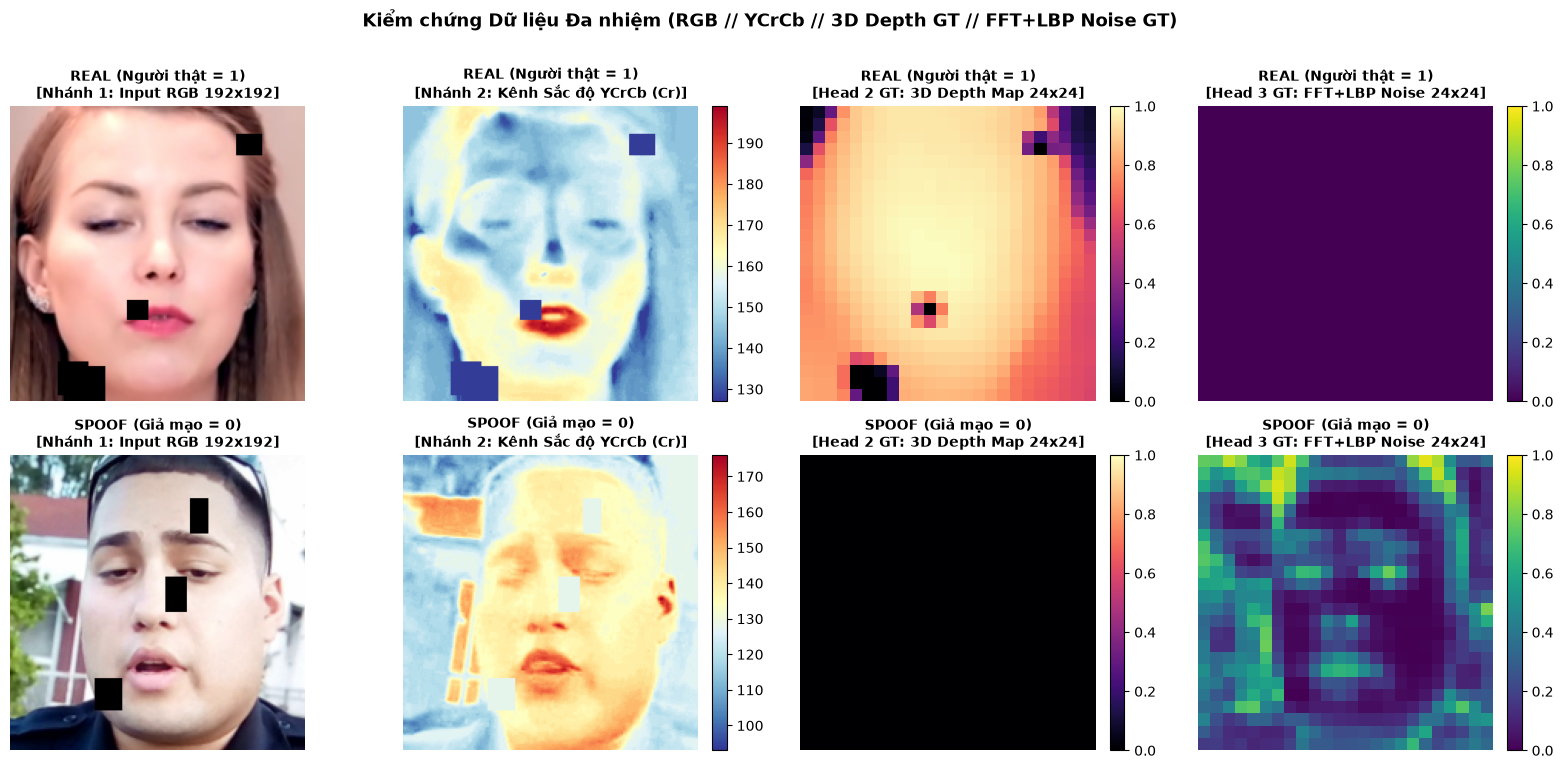

In [9]:
# === CELL 7: WEIGHTED RANDOM SAMPLER (CÂN BẰNG LỚP 50/50) & KIỂM TRA TRỰC QUAN ĐA NHIỆM ===
def build_weighted_sampler(samples):
    labels = [label for _, label in samples]
    counts = Counter(labels)
    class_weights = {cls: 1.0 / max(cnt, 1) for cls, cnt in counts.items()}
    sample_weights = torch.DoubleTensor([class_weights[label] for label in labels])
    return WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        replacement=True,
    )

def make_dataloaders(batch_size: int = BATCH_SIZE):
    sampler = build_weighted_sampler(train_samples)
    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        sampler=sampler,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        drop_last=True,
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
    )
    return train_loader, val_loader

# --- Kiểm tra 1 Mini-batch và Trực quan hóa Ảnh RGB + Kênh sắc độ CrCb + 3D Depth GT + FFT/LBP Noise GT ---
_vis_loader, _ = make_dataloaders(batch_size=8)
_imgs, _lbls, _depths, _noises = next(iter(_vis_loader))
del _vis_loader

print(f"✅ Kiểm tra Shape Mini-Batch Đa nhiệm:")
print(f"   - Images (RGB) : {tuple(_imgs.shape)} | dtype={_imgs.dtype}")
print(f"   - Labels       : {_lbls.tolist()} (Real={int((_lbls==1).sum())}/8, Spoof={int((_lbls==0).sum())}/8)")
print(f"   - Depth GT Map : {tuple(_depths.shape)} | min={_depths.min():.2f}, max={_depths.max():.2f}")
print(f"   - Noise GT Map : {tuple(_noises.shape)} | min={_noises.min():.2f}, max={_noises.max():.2f}")

# Chọn 1 mẫu Real và 1 mẫu Spoof điển hình trong batch để hiển thị đối chứng
_real_idx  = int((_lbls == 1).nonzero(as_tuple=True)[0][0]) if (_lbls == 1).any() else 0
_spoof_idx = int((_lbls == 0).nonzero(as_tuple=True)[0][0]) if (_lbls == 0).any() else 1

fig, axes = plt.subplots(2, 4, figsize=(16, 7.5))
for row_i, (sample_idx, title_prefix) in enumerate([(_real_idx, "REAL (Người thật = 1)"), (_spoof_idx, "SPOOF (Giả mạo = 0)")]):
    # Khử chuẩn hóa ImageNet để hiển thị RGB
    img_np = _imgs[sample_idx].permute(1, 2, 0).numpy()
    img_np = np.clip(img_np * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN), 0.0, 1.0)
    img_u8 = (img_np * 255.0).astype(np.uint8)

    # Chuyển sang không gian YCrCb để quan sát kênh sắc độ Cr (Đỏ) và Cb (Xanh)
    ycrcb_u8 = cv2.cvtColor(img_u8, cv2.COLOR_RGB2YCrCb)
    crcb_vis = ycrcb_u8[:, :, 1]  # Kênh sắc độ Cr phản ánh rõ sắc tố sinh học da người

    depth_np = _depths[sample_idx, 0].numpy()
    noise_np = _noises[sample_idx, 0].numpy()

    axes[row_i, 0].imshow(img_np)
    axes[row_i, 0].set_title(f"{title_prefix}\n[Nhánh 1: Input RGB 192x192]", fontweight="bold", fontsize=10)
    axes[row_i, 0].axis("off")

    im1 = axes[row_i, 1].imshow(crcb_vis, cmap="RdYlBu_r")
    axes[row_i, 1].set_title(f"{title_prefix}\n[Nhánh 2: Kênh Sắc độ YCrCb (Cr)]", fontweight="bold", fontsize=10)
    axes[row_i, 1].axis("off")
    plt.colorbar(im1, ax=axes[row_i, 1], fraction=0.046, pad=0.04)

    im2 = axes[row_i, 2].imshow(depth_np, cmap="magma", vmin=0.0, vmax=1.0)
    axes[row_i, 2].set_title(f"{title_prefix}\n[Head 2 GT: 3D Depth Map 24x24]", fontweight="bold", fontsize=10)
    axes[row_i, 2].axis("off")
    plt.colorbar(im2, ax=axes[row_i, 2], fraction=0.046, pad=0.04)

    im3 = axes[row_i, 3].imshow(noise_np, cmap="viridis", vmin=0.0, vmax=1.0)
    axes[row_i, 3].set_title(f"{title_prefix}\n[Head 3 GT: FFT+LBP Noise 24x24]", fontweight="bold", fontsize=10)
    axes[row_i, 3].axis("off")
    plt.colorbar(im3, ax=axes[row_i, 3], fraction=0.046, pad=0.04)

plt.suptitle("Kiểm chứng Dữ liệu Đa nhiệm (RGB // YCrCb // 3D Depth GT // FFT+LBP Noise GT)", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()
del _imgs, _lbls, _depths, _noises

In [10]:
# === CELL 8: KIẾN TRÚC ĐA NHIỆM DualSpaceMultiTaskFASNet (RGB // YCrCb + FPN + DEPTH/NOISE + PHYSICS GATING) ===
def disable_inplace_activations(module: nn.Module):
    """Tắt inplace=True trong toàn bộ các tầng kích hoạt để chạy an toàn với bfloat16 trên Intel XPU."""
    for m in module.modules():
        if hasattr(m, "inplace") and isinstance(m.inplace, bool):
            m.inplace = False


class Conv2d_CD(nn.Module):
    """Tích chập Sai phân Trung tâm (Central Difference Convolution) kế thừa từ Stage 1."""
    def __init__(self, in_channels: int, out_channels: int, kernel_size: int = 3, stride: int = 1,
                 padding: int = 1, dilation: int = 1, groups: int = 1, bias: bool = False, theta: float = 0.4):
        super().__init__()
        self.conv = nn.Conv2d(
            in_channels, out_channels, kernel_size=kernel_size, stride=stride,
            padding=padding, dilation=dilation, groups=groups, bias=bias
        )
        self.theta = float(theta)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out_normal = self.conv(x)
        if abs(self.theta) < 1e-8:
            return out_normal
        kernel_diff = self.conv.weight.sum(dim=(2, 3), keepdim=True)
        out_diff = F.conv2d(
            input=x, weight=kernel_diff, bias=None,
            stride=self.conv.stride, padding=0, groups=self.conv.groups
        )
        return out_normal - self.theta * out_diff


class SEBlock(nn.Module):
    """Khối chú ý kênh Squeeze-and-Excitation (inplace=False)."""
    def __init__(self, channels: int, reduction: int = 8):
        super().__init__()
        mid_c = max(channels // reduction, 8)
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, mid_c, bias=False),
            nn.SiLU(inplace=False),
            nn.Linear(mid_c, channels, bias=False),
            nn.Sigmoid(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y


class ResidualCDBlock(nn.Module):
    """Khối Residual kết hợp Tích chập Sai phân Trung tâm (Conv2d_CD) và SE-Attention."""
    def __init__(self, in_c: int, out_c: int, stride: int = 1, theta: float = 0.4):
        super().__init__()
        self.conv1 = Conv2d_CD(in_c, out_c, kernel_size=3, stride=stride, padding=1, theta=theta)
        self.bn1   = nn.BatchNorm2d(out_c)
        self.act1  = nn.SiLU(inplace=False)
        self.conv2 = Conv2d_CD(out_c, out_c, kernel_size=3, stride=1, padding=1, theta=theta)
        self.bn2   = nn.BatchNorm2d(out_c)
        self.se    = SEBlock(out_c, reduction=8)
        self.act2  = nn.SiLU(inplace=False)

        if stride != 1 or in_c != out_c:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_c, out_c, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_c),
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        identity = self.shortcut(x)
        out = self.act1(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = self.se(out)
        return self.act2(out + identity)


class DilatedResidualBlock(nn.Module):
    """Khối Tích chập Giãn nở (Dilated Residual) mở rộng vùng cảm thụ 3D trên lưới 24x24."""
    def __init__(self, channels: int, dilation: int = 2):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, kernel_size=3, padding=dilation, dilation=dilation, bias=False),
            nn.BatchNorm2d(channels),
            nn.SiLU(inplace=False),
            nn.Conv2d(channels, channels, kernel_size=3, padding=1, dilation=1, bias=False),
            nn.BatchNorm2d(channels),
        )
        self.act = nn.SiLU(inplace=False)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.act(x + self.block(x))


class SpatialAttentionGate(nn.Module):
    """Cổng Chú ý Không gian (CBAM Spatial Gate) khoanh vùng đốm phản xạ và sóng màn hình."""
    def __init__(self, kernel_size: int = 7):
        super().__init__()
        pad = kernel_size // 2
        self.conv = nn.Conv2d(2, 1, kernel_size=kernel_size, padding=pad, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        scale = self.sigmoid(self.conv(torch.cat([avg_out, max_out], dim=1)))
        return x * scale


class DifferentiableRGBToYCrCb(nn.Module):
    """
    Toán tử chuyển đổi khả vi từ Tensor RGB (đã chuẩn hóa ImageNet) sang không gian màu YCrCb
    chạy trực tiếp trên GPU XPU (Không cần lưu thêm dữ liệu trong RAM).
    """
    def __init__(self):
        super().__init__()
        self.register_buffer("mean", torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1))
        self.register_buffer("std",  torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1))

    def forward(self, x_norm: torch.Tensor) -> torch.Tensor:
        # Khôi phục về RGB [0, 1]
        rgb = (x_norm * self.std + self.mean).clamp(0.0, 1.0)
        r, g, b = rgb[:, 0:1], rgb[:, 1:2], rgb[:, 2:3]

        # Công thức chuẩn ITU-R BT.601 chuyển sang Y, Cr, Cb và chuẩn hóa về [-1, 1]
        y  = 0.299 * r + 0.587 * g + 0.114 * b
        cr = (r - y) * 0.713 + 0.5
        cb = (b - y) * 0.564 + 0.5
        ycrcb = torch.cat([y, cr, cb], dim=1)
        return (ycrcb - 0.5) / 0.5


class MultiTaskFASNet(nn.Module):
    """
    Kiến trúc Đa nhiệm Song song & Nối tiếp (Model 3):
      1. Nhánh Song song 1 (RGB): Shared Encoder MobileNetV3-Large (trích xuất 3 tầng 24x24, 12x12, 6x6) + FPN Neck (256 kênh).
      2. Nhánh Song song 2 (YCrCb): Chuyển hệ màu YCrCb trên GPU + Chuỗi ResidualCDBlock (64 kênh @ 24x24).
      3. Hợp nhất Đa không gian (Cross-Space SE Fusion): (256 + 64) -> 256 kênh @ 24x24.
      4. Hai Nhánh Giải mã Song song:
         - Head 2 (3D Depth Decoder): Chuỗi DilatedResidualBlock (d=1, 2, 4) -> Bản đồ Depth (B, 1, 24, 24).
         - Head 3 (Noise/Moiré Decoder): Chuỗi ResidualCDBlock + SpatialAttentionGate -> Bản đồ Noise (B, 1, 24, 24).
      5. Cầu nối Vật lý (Physics-Guided Gating) & Head 1 (Classifier):
         - Kết hợp Vector Ngữ cảnh Backbone (1920D) + Vector Vật lý Depth/Noise (512D) = 2432D -> Logits (B, 2).
    """
    def __init__(
        self,
        backbone_name: str = "mobilenet_v3_large",
        num_classes: int = NUM_CLASSES,
        dropout_rate: float = 0.40,
        theta_cd: float = 0.40,
        pretrained_imagenet: bool = True,
    ):
        super().__init__()
        self.backbone_name = backbone_name.lower()
        self.num_classes = num_classes
        self.dropout_rate = float(dropout_rate)
        self.theta_cd = float(theta_cd)
        self.backbone_frozen = False

        assert self.backbone_name == "mobilenet_v3_large", "Stage 3 chốt sử dụng Winner Backbone 'mobilenet_v3_large'."
        weights = tv_models.MobileNet_V3_Large_Weights.DEFAULT if pretrained_imagenet else None
        base = tv_models.mobilenet_v3_large(weights=weights)
        self.encoder = base.features  # Giữ nguyên cấu trúc self.encoder để nạp khớp 100% trọng số từ Stage 2
        disable_inplace_activations(self.encoder)

        # --- Nhánh Song song 2: Không gian Sắc độ YCrCb + Central Difference Stem (192 -> 96 -> 48 -> 24) ---
        self.rgb_to_ycrcb = DifferentiableRGBToYCrCb()
        self.ycrcb_stem = nn.Sequential(
            Conv2d_CD(3, 32, kernel_size=3, stride=2, padding=1, theta=theta_cd),
            nn.BatchNorm2d(32),
            nn.SiLU(inplace=False),
            ResidualCDBlock(32, 48, stride=2, theta=theta_cd),  # 96 -> 48
            ResidualCDBlock(48, 64, stride=2, theta=theta_cd),  # 48 -> 24 (B, 64, 24, 24)
        )

        # --- Tháp Đặc trưng Đa tỷ lệ Nối tiếp (Cascaded Multi-Scale FPN Neck -> 256 kênh @ 24x24) ---
        self.lat_s6 = nn.Sequential(nn.Conv2d(960, 256, kernel_size=1, bias=False), nn.BatchNorm2d(256), nn.SiLU(inplace=False))
        self.lat_s4 = nn.Sequential(nn.Conv2d(112, 256, kernel_size=1, bias=False), nn.BatchNorm2d(256), nn.SiLU(inplace=False))
        self.lat_s2 = nn.Sequential(nn.Conv2d(40,  256, kernel_size=1, bias=False), nn.BatchNorm2d(256), nn.SiLU(inplace=False))

        self.smooth_s4 = nn.Sequential(
            nn.Conv2d(256, 256, kernel_size=3, padding=1, groups=256, bias=False),
            nn.Conv2d(256, 256, kernel_size=1, bias=False),
            nn.BatchNorm2d(256),
            nn.SiLU(inplace=False),
        )
        self.smooth_s2 = nn.Sequential(
            nn.Conv2d(256, 256, kernel_size=3, padding=1, groups=256, bias=False),
            nn.Conv2d(256, 256, kernel_size=1, bias=False),
            nn.BatchNorm2d(256),
            nn.SiLU(inplace=False),
        )

        # --- Hợp nhất Đa không gian màu (RGB FPN 256ch + YCrCb 64ch = 320ch -> 256ch) ---
        self.fusion_neck = nn.Sequential(
            nn.Conv2d(256 + 64, 256, kernel_size=1, bias=False),
            nn.BatchNorm2d(256),
            nn.SiLU(inplace=False),
            SEBlock(256, reduction=8),
        )

        # --- Head 2: Nhánh Giải mã Độ sâu 3D (Dilated Residual Decoder -> 128 kênh @ 24x24) ---
        self.depth_decoder_feat = nn.Sequential(
            nn.Conv2d(256, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.SiLU(inplace=False),
            DilatedResidualBlock(128, dilation=1),
            DilatedResidualBlock(128, dilation=2),
            DilatedResidualBlock(128, dilation=4),
        )
        self.depth_pred_head = nn.Sequential(
            nn.Conv2d(128, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.SiLU(inplace=False),
            nn.Conv2d(32, 1, kernel_size=1),
            nn.Sigmoid(),
        )

        # --- Head 3: Nhánh Giải mã Nhiễu Moiré & Phản xạ (Central Difference + Spatial Gate -> 128 kênh @ 24x24) ---
        self.noise_decoder_feat = nn.Sequential(
            ResidualCDBlock(256, 128, stride=1, theta=theta_cd),
            ResidualCDBlock(128, 128, stride=1, theta=theta_cd),
            SpatialAttentionGate(kernel_size=7),
        )
        self.noise_pred_head = nn.Sequential(
            nn.Conv2d(128, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.SiLU(inplace=False),
            nn.Conv2d(32, 1, kernel_size=1),
            nn.Sigmoid(),
        )

        # --- Cầu nối Tương tác Vật lý (Physics-Guided Pooling) & Head 1 (Classifier) ---
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)

        # Tổng chiều đặc trưng = 1920D (Backbone Dual Pool) + 256D (Depth Gate Pool) + 256D (Noise Gate Pool) = 2432D
        self.backbone_feat_dim = 960 * 2
        self.physics_feat_dim  = (128 * 2) + (128 * 2)
        self.feature_dim       = self.backbone_feat_dim + self.physics_feat_dim  # 2432D

        self.classifier = nn.Sequential(
            nn.Linear(self.feature_dim, 512, bias=False),
            nn.BatchNorm1d(512),
            nn.SiLU(inplace=False),
            nn.Dropout(p=self.dropout_rate),
            nn.Linear(512, 256, bias=False),
            nn.BatchNorm1d(256),
            nn.SiLU(inplace=False),
            nn.Dropout(p=self.dropout_rate * 0.75),
            nn.Linear(256, num_classes),
        )

        disable_inplace_activations(self)

    def _dual_pool(self, fmap: torch.Tensor) -> torch.Tensor:
        return torch.cat([self.avg_pool(fmap).flatten(1), self.max_pool(fmap).flatten(1)], dim=1)

    def _forward_rgb_backbone(self, x: torch.Tensor):
        f_s2 = self.encoder[:7](x)      # (B, 40,  24, 24)
        f_s4 = self.encoder[7:13](f_s2) # (B, 112, 12, 12)
        f_s6 = self.encoder[13:](f_s4)  # (B, 960,  6,  6)
        return f_s2, f_s4, f_s6

    def forward_multitask(self, x: torch.Tensor):
        # 1. Nhánh RGB Backbone (Đóng băng đạo hàm nếu ở pha Warmup)
        if self.backbone_frozen:
            with torch.no_grad():
                f_s2, f_s4, f_s6 = self._forward_rgb_backbone(x)
        else:
            f_s2, f_s4, f_s6 = self._forward_rgb_backbone(x)

        # 2. Tháp FPN nối tiếp (6x6 -> 12x12 -> 24x24)
        p6 = self.lat_s6(f_s6)
        p4 = self.smooth_s4(self.lat_s4(f_s4) + F.interpolate(p6, size=f_s4.shape[-2:], mode="bilinear", align_corners=False))
        p2 = self.smooth_s2(self.lat_s2(f_s2) + F.interpolate(p4, size=f_s2.shape[-2:], mode="bilinear", align_corners=False))

        # 3. Nhánh YCrCb chạy song song & Hợp nhất Đa không gian màu
        ycrcb_img  = self.rgb_to_ycrcb(x)
        f_ycrcb    = self.ycrcb_stem(ycrcb_img)  # (B, 64, 24, 24)
        f_fused    = self.fusion_neck(torch.cat([p2, f_ycrcb], dim=1))  # (B, 256, 24, 24)

        # 4. Giải mã song song Bản đồ 3D Depth & Bản đồ Nhiễu Moiré
        d_feat     = self.depth_decoder_feat(f_fused)   # (B, 128, 24, 24)
        pred_depth = self.depth_pred_head(d_feat)       # (B,   1, 24, 24)

        n_feat     = self.noise_decoder_feat(f_fused)   # (B, 128, 24, 24)
        pred_noise = self.noise_pred_head(n_feat)       # (B,   1, 24, 24)

        # 5. Cầu nối Tương tác Vật lý (Physics-Guided Gating)
        gated_d = d_feat * (1.0 + pred_depth)
        gated_n = n_feat * (1.0 + pred_noise)

        vec_backbone = self._dual_pool(f_s6)     # (B, 1920)
        vec_depth    = self._dual_pool(gated_d)  # (B, 256)
        vec_noise    = self._dual_pool(gated_n)  # (B, 256)

        joint_features = torch.cat([vec_backbone, vec_depth, vec_noise], dim=1)  # (B, 2432)
        logits = self.classifier(joint_features)
        return logits, pred_depth, pred_noise

    def extract_features(self, x: torch.Tensor) -> torch.Tensor:
        """Trích xuất vector đặc trưng hợp nhất 2432 chiều."""
        f_s2, f_s4, f_s6 = self._forward_rgb_backbone(x)
        p6 = self.lat_s6(f_s6)
        p4 = self.smooth_s4(self.lat_s4(f_s4) + F.interpolate(p6, size=f_s4.shape[-2:], mode="bilinear", align_corners=False))
        p2 = self.smooth_s2(self.lat_s2(f_s2) + F.interpolate(p4, size=f_s2.shape[-2:], mode="bilinear", align_corners=False))
        f_ycrcb = self.ycrcb_stem(self.rgb_to_ycrcb(x))
        f_fused = self.fusion_neck(torch.cat([p2, f_ycrcb], dim=1))
        d_feat  = self.depth_decoder_feat(f_fused)
        pred_d  = self.depth_pred_head(d_feat)
        n_feat  = self.noise_decoder_feat(f_fused)
        pred_n  = self.noise_pred_head(n_feat)
        return torch.cat([
            self._dual_pool(f_s6),
            self._dual_pool(d_feat * (1.0 + pred_d)),
            self._dual_pool(n_feat * (1.0 + pred_n)),
        ], dim=1)

    def forward(self, x: torch.Tensor, return_maps: bool = False):
        logits, pred_depth, pred_noise = self.forward_multitask(x)
        if return_maps:
            return logits, pred_depth, pred_noise
        return logits

    def set_backbone_trainable(self, trainable: bool = True):
        self.backbone_frozen = not trainable
        for param in self.encoder.parameters():
            param.requires_grad = trainable
        if not trainable:
            self.encoder.eval()

    def train(self, mode: bool = True):
        super().train(mode)
        if mode and self.backbone_frozen:
            self.encoder.eval()
        return self


def build_multitask_model(
    init_mode: str = "stage2_warmstart",
    dropout_rate: float = 0.40,
    theta_cd: float = THETA_CD,
) -> MultiTaskFASNet:
    """
    Khởi tạo MultiTaskFASNet theo 1 trong 2 chế độ:
      - 'stage2_warmstart'   : Nạp trọng số encoder đã tinh chỉnh từ model2_transfer_best.pt (Stage 2).
      - 'imagenet_freshstart': Khởi tạo encoder từ trọng số ImageNet gốc của torchvision.
    """
    init_mode = init_mode.lower()
    use_imagenet = (init_mode == "imagenet_freshstart") or (not MODEL2_BEST_CKPT_PATH.exists())
    model = MultiTaskFASNet(
        backbone_name=BACKBONE_NAME,
        num_classes=NUM_CLASSES,
        dropout_rate=dropout_rate,
        theta_cd=theta_cd,
        pretrained_imagenet=use_imagenet,
    )

    if init_mode == "stage2_warmstart" and MODEL2_BEST_CKPT_PATH.exists():
        s2_ckpt = torch.load(MODEL2_BEST_CKPT_PATH, map_location="cpu")
        s2_sd = s2_ckpt.get("model_state_dict", s2_ckpt)
        encoder_sd = {k.replace("encoder.", ""): v for k, v in s2_sd.items() if k.startswith("encoder.")}
        missing, unexpected = model.encoder.load_state_dict(encoder_sd, strict=True)
    return model


# Kiểm tra nhanh kích thước Tensor trên CPU (Tránh khởi tạo context XPU trước khi fork DataLoader)
_dummy_in = torch.randn(2, 3, IMG_SIZE, IMG_SIZE)
_test_net = build_multitask_model(init_mode="stage2_warmstart").eval()
with torch.no_grad():
    _logits, _p_depth, _p_noise = _test_net(_dummy_in, return_maps=True)
    _joint_vec = _test_net.extract_features(_dummy_in)
_total_params = sum(p.numel() for p in _test_net.parameters()) / 1e6
_enc_params   = sum(p.numel() for p in _test_net.encoder.parameters()) / 1e6
_head_params  = _total_params - _enc_params

print("=== KIỂM TRA KIẾN TRÚC ĐA NHIỆM DualSpaceMultiTaskFASNet ===")
print(f"  - Tổng tham số mạng  : {_total_params:.2f}M (Shared Backbone: {_enc_params:.2f}M | Multi-task Heads & Neck: {_head_params:.2f}M)")
print(f"  - Joint Feature Vec  : {tuple(_joint_vec.shape)} (1920D Backbone + 512D Physics Gating)")
print(f"  - Output Logits      : {tuple(_logits.shape)}")
print(f"  - Pred Depth Map 3D  : {tuple(_p_depth.shape)} | range=[{_p_depth.min():.2f}, {_p_depth.max():.2f}]")
print(f"  - Pred Noise Map     : {tuple(_p_noise.shape)} | range=[{_p_noise.min():.2f}, {_p_noise.max():.2f}]")
del _dummy_in, _test_net, _logits, _p_depth, _p_noise, _joint_vec

=== KIỂM TRA KIẾN TRÚC ĐA NHIỆM DualSpaceMultiTaskFASNet ===
  - Tổng tham số mạng  : 7.01M (Shared Backbone: 2.97M | Multi-task Heads & Neck: 4.04M)
  - Joint Feature Vec  : (2, 2432) (1920D Backbone + 512D Physics Gating)
  - Output Logits      : (2, 2)
  - Pred Depth Map 3D  : (2, 1, 24, 24) | range=[0.52, 0.52]
  - Pred Noise Map     : (2, 1, 24, 24) | range=[0.46, 0.46]


In [11]:
# === CELL 9: HÀM LOSS ĐA NHIỆM (FOCAL + 3D DEPTH GRADIENT LOSS + NOISE LOSS) & ISO/IEC 30107-3 ===
class FocalLossWithSmoothing(nn.Module):
    """Hàm mất mát phân loại chính kết hợp Focal Loss và Label Smoothing kế thừa từ Stage 1 & 2."""
    def __init__(self, gamma: float = 2.0, alpha_real: float = 0.55, smoothing: float = 0.08):
        super().__init__()
        self.gamma = gamma
        self.alpha_real = alpha_real
        self.smoothing = smoothing

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        num_classes = logits.size(-1)
        with torch.no_grad():
            true_dist = torch.zeros_like(logits)
            true_dist.fill_(self.smoothing / num_classes)
            true_dist.scatter_(1, targets.unsqueeze(1), 1.0 - self.smoothing + (self.smoothing / num_classes))

        log_probs = F.log_softmax(logits.float(), dim=-1)
        probs = torch.exp(log_probs)

        pt = (true_dist * probs).sum(dim=-1)
        ce_smooth = -(true_dist * log_probs).sum(dim=-1)

        alpha_t = torch.where(targets == 1, self.alpha_real, 1.0 - self.alpha_real)
        focal_weight = alpha_t * ((1.0 - pt) ** self.gamma)
        return (focal_weight * ce_smooth).mean()


class DepthRegressionLoss(nn.Module):
    """
    Hàm Loss cho Nhánh Độ sâu 3D (Head 2):
      - Kết hợp Smooth L1 (Huber) đo sai số từng điểm ảnh + Spatial Gradient Loss đo độ dốc 3D theo trục X, Y.
    """
    def __init__(self, grad_weight: float = 0.5):
        super().__init__()
        self.grad_weight = grad_weight

    def forward(self, pred_d: torch.Tensor, gt_d: torch.Tensor) -> torch.Tensor:
        pred_f = pred_d.float()
        gt_f   = gt_d.float()
        pixel_loss = F.smooth_l1_loss(pred_f, gt_f, beta=0.05)

        # Sai số đạo hàm không gian (Spatial Gradient) giúp giữ hình khối lồi lõm của mũi/hốc mắt
        dx_pred = pred_f[:, :, :, 1:] - pred_f[:, :, :, :-1]
        dx_gt   = gt_f[:, :, :, 1:]   - gt_f[:, :, :, :-1]
        dy_pred = pred_f[:, :, 1:, :] - pred_f[:, :, :-1, :]
        dy_gt   = gt_f[:, :, 1:, :]   - gt_f[:, :, :-1, :]

        grad_loss = F.l1_loss(dx_pred, dx_gt) + F.l1_loss(dy_pred, dy_gt)
        return pixel_loss + self.grad_weight * grad_loss


class CompositeMultiTaskLoss(nn.Module):
    """
    Hàm Mục tiêu Đa nhiệm Tổng hợp:
      L_total = L_Focal_Cls + lambda_depth * L_Depth + lambda_noise * L_Noise
    """
    def __init__(
        self,
        gamma: float = FOCAL_GAMMA,
        alpha_real: float = ALPHA_REAL,
        smoothing: float = LABEL_SMOOTHING,
        lambda_depth: float = 0.50,
        lambda_noise: float = 0.40,
    ):
        super().__init__()
        self.cls_criterion   = FocalLossWithSmoothing(gamma=gamma, alpha_real=alpha_real, smoothing=smoothing)
        self.depth_criterion = DepthRegressionLoss(grad_weight=0.5)
        self.lambda_depth    = float(lambda_depth)
        self.lambda_noise    = float(lambda_noise)

    def forward(
        self,
        logits: torch.Tensor,
        pred_depth: torch.Tensor,
        pred_noise: torch.Tensor,
        labels: torch.Tensor,
        gt_depth: torch.Tensor,
        gt_noise: torch.Tensor,
    ):
        loss_cls   = self.cls_criterion(logits, labels)
        loss_depth = self.depth_criterion(pred_depth, gt_depth)
        loss_noise = 0.7 * F.smooth_l1_loss(pred_noise.float(), gt_noise.float(), beta=0.05) + 0.3 * F.mse_loss(pred_noise.float(), gt_noise.float())

        total_loss = loss_cls + self.lambda_depth * loss_depth + self.lambda_noise * loss_noise
        return total_loss, {
            "total": float(total_loss.detach().item()),
            "cls":   float(loss_cls.detach().item()),
            "depth": float(loss_depth.detach().item()),
            "noise": float(loss_noise.detach().item()),
        }


def compute_fas_metrics(y_true: np.ndarray, y_prob_real: np.ndarray, fixed_threshold: float = None):
    """Tính bộ chỉ số chuẩn quốc tế ISO/IEC 30107-3: APCER, BPCER, ACER, EER, ROC-AUC, ACC."""
    y_true = np.asarray(y_true, dtype=np.int64)
    y_prob = np.asarray(y_prob_real, dtype=np.float64)

    auc = float(roc_auc_score(y_true, y_prob)) if len(np.unique(y_true)) > 1 else 0.5
    fpr, tpr, thresholds = roc_curve(y_true, y_prob, pos_label=1)
    fnr = 1.0 - tpr

    eer_idx = int(np.nanargmin(np.abs(fpr - fnr)))
    eer_threshold = float(thresholds[eer_idx])
    eer = float((fpr[eer_idx] + fnr[eer_idx]) / 2.0)

    thresh = float(eer_threshold if fixed_threshold is None else fixed_threshold)
    y_pred = (y_prob >= thresh).astype(np.int64)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    apcer = float(fp / max(tn + fp, 1))
    bpcer = float(fn / max(tp + fn, 1))
    acer  = float((apcer + bpcer) / 2.0)
    acc   = float((tp + tn) / max(tp + tn + fp + fn, 1))

    return {
        "threshold": thresh,
        "eer_threshold": eer_threshold,
        "APCER": apcer * 100.0,
        "BPCER": bpcer * 100.0,
        "ACER": acer * 100.0,
        "EER": eer * 100.0,
        "AUC": auc * 100.0,
        "ACC": acc * 100.0,
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
    }

print("✅ Đã khởi tạo CompositeMultiTaskLoss và bộ chỉ số đánh giá chuẩn ISO/IEC 30107-3!")

✅ Đã khởi tạo CompositeMultiTaskLoss và bộ chỉ số đánh giá chuẩn ISO/IEC 30107-3!


In [12]:
# === CELL 10: HÀM TRAIN / EVALUATE ĐA NHIỆM & DIFFERENTIAL LR OPTIMIZER (CHUẨN XPU) ===
def build_multitask_optimizer(
    model: MultiTaskFASNet,
    lr_head: float,
    backbone_lr_ratio: float,
    weight_decay: float,
):
    """
    Tách biệt tốc độ học giữa:
      - Nhóm 1 (Shared Backbone encoder): lr = lr_head * backbone_lr_ratio
      - Nhóm 2 (Multi-task Heads: YCrCb Stem + FPN Neck + Depth/Noise Decoders + Classifier): lr = lr_head
    """
    lr_backbone = lr_head * backbone_lr_ratio
    backbone_params = list(model.encoder.parameters())
    backbone_Param_ids = {id(p) for p in backbone_params}
    head_params = [p for p in model.parameters() if id(p) not in backbone_Param_ids]

    param_groups = [
        {"params": backbone_params, "lr": lr_backbone, "name": "backbone"},
        {"params": head_params,     "lr": lr_head,     "name": "multitask_heads"},
    ]
    return torch.optim.AdamW(param_groups, weight_decay=weight_decay)


def train_one_epoch_multitask(
    model: MultiTaskFASNet,
    loader: DataLoader,
    criterion: CompositeMultiTaskLoss,
    optimizer: torch.optim.Optimizer,
):
    model.train()
    sum_total, sum_cls, sum_depth, sum_noise = 0.0, 0.0, 0.0, 0.0
    total_samples = 0
    trainable_params = [p for p in model.parameters() if p.requires_grad]

    for images, labels, gt_depth, gt_noise in loader:
        if USE_CHANNELS_LAST:
            images = images.to(DEVICE, non_blocking=True, memory_format=torch.channels_last)
        else:
            images = images.to(DEVICE, non_blocking=True)
        labels   = labels.to(DEVICE, non_blocking=True)
        gt_depth = gt_depth.to(DEVICE, non_blocking=True)
        gt_noise = gt_noise.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast(device_type=AUTOCAST_DEVICE_TYPE, dtype=AUTOCAST_DTYPE, enabled=USE_AMP):
            logits, pred_depth, pred_noise = model(images, return_maps=True)
            loss, loss_dict = criterion(logits, pred_depth, pred_noise, labels, gt_depth, gt_noise)

        loss.backward()
        if trainable_params:
            torch.nn.utils.clip_grad_norm_(trainable_params, max_norm=2.0)
        optimizer.step()

        bs = labels.size(0)
        sum_total += loss_dict["total"] * bs
        sum_cls   += loss_dict["cls"]   * bs
        sum_depth += loss_dict["depth"] * bs
        sum_noise += loss_dict["noise"] * bs
        total_samples += bs

    if has_xpu:
        torch.xpu.synchronize()

    denom = max(total_samples, 1)
    return {
        "loss":       sum_total / denom,
        "cls_loss":   sum_cls   / denom,
        "depth_loss": sum_depth / denom,
        "noise_loss": sum_noise / denom,
    }


@torch.no_grad()
def evaluate_multitask_model(
    model: MultiTaskFASNet,
    loader: DataLoader,
    criterion: CompositeMultiTaskLoss,
    fixed_threshold: float = None,
):
    model.eval()
    sum_total, sum_cls, sum_depth, sum_noise = 0.0, 0.0, 0.0, 0.0
    total_samples = 0
    all_labels = []
    all_probs_real = []

    for images, labels, gt_depth, gt_noise in loader:
        if USE_CHANNELS_LAST:
            images = images.to(DEVICE, non_blocking=True, memory_format=torch.channels_last)
        else:
            images = images.to(DEVICE, non_blocking=True)
        labels_dev = labels.to(DEVICE, non_blocking=True)
        gt_depth   = gt_depth.to(DEVICE, non_blocking=True)
        gt_noise   = gt_noise.to(DEVICE, non_blocking=True)

        with torch.amp.autocast(device_type=AUTOCAST_DEVICE_TYPE, dtype=AUTOCAST_DTYPE, enabled=USE_AMP):
            logits, pred_depth, pred_noise = model(images, return_maps=True)
            _, loss_dict = criterion(logits, pred_depth, pred_noise, labels_dev, gt_depth, gt_noise)
            probs_real = F.softmax(logits.float(), dim=-1)[:, 1]

        bs = labels.size(0)
        sum_total += loss_dict["total"] * bs
        sum_cls   += loss_dict["cls"]   * bs
        sum_depth += loss_dict["depth"] * bs
        sum_noise += loss_dict["noise"] * bs
        total_samples += bs

        all_labels.append(labels.numpy())
        all_probs_real.append(probs_real.cpu().numpy())

    if has_xpu:
        torch.xpu.synchronize()

    y_true = np.concatenate(all_labels)
    y_prob = np.concatenate(all_probs_real)
    metrics = compute_fas_metrics(y_true, y_prob, fixed_threshold=fixed_threshold)
    denom = max(total_samples, 1)
    metrics["loss"]       = sum_total / denom
    metrics["cls_loss"]   = sum_cls   / denom
    metrics["depth_loss"] = sum_depth / denom
    metrics["noise_loss"] = sum_noise / denom
    metrics["y_true"]     = y_true
    metrics["y_prob"]     = y_prob
    return metrics

print("✅ Các hàm train_one_epoch_multitask, evaluate_multitask_model & build_multitask_optimizer đã sẵn sàng!")

✅ Các hàm train_one_epoch_multitask, evaluate_multitask_model & build_multitask_optimizer đã sẵn sàng!


## Trainning

### PHA 1 - ĐỌ SỨC 2 CHẾ ĐỘ KHỞI TẠO BACKBONE (STAGE2_WARMSTART vs IMAGENET_FRESHSTART)

In [13]:
# === CELL 11: PHA 1 - ĐỌ SỨC 2 CHẾ ĐỘ KHỞI TẠO BACKBONE (STAGE2_WARMSTART vs IMAGENET_FRESHSTART) ===
SCREEN_DEFAULT_LR_HEAD        = float(DEFAULT_STAGE2_PARAMS["lr_head"])
SCREEN_DEFAULT_BACKBONE_RATIO = float(DEFAULT_STAGE2_PARAMS["backbone_lr_ratio"])
SCREEN_DEFAULT_WEIGHT_DECAY   = float(DEFAULT_STAGE2_PARAMS["weight_decay"])
SCREEN_DEFAULT_DROPOUT        = float(DEFAULT_STAGE2_PARAMS["dropout_rate"])
SCREEN_DEFAULT_LAMBDA_DEPTH   = 0.50
SCREEN_DEFAULT_LAMBDA_NOISE   = 0.40

screening_config_signature = {
    "candidate_init_modes": CANDIDATE_INIT_MODES,
    "backbone_name": BACKBONE_NAME,
    "img_size": IMG_SIZE,
    "map_size": MAP_SIZE,
    "batch_size": BATCH_SIZE,
    "freeze_epochs": SCREEN_FREEZE_EPOCHS,
    "lr_head": round(SCREEN_DEFAULT_LR_HEAD, 8),
    "backbone_lr_ratio": round(SCREEN_DEFAULT_BACKBONE_RATIO, 8),
    "weight_decay": round(SCREEN_DEFAULT_WEIGHT_DECAY, 8),
    "dropout_rate": round(SCREEN_DEFAULT_DROPOUT, 4),
    "lambda_depth": SCREEN_DEFAULT_LAMBDA_DEPTH,
    "lambda_noise": SCREEN_DEFAULT_LAMBDA_NOISE,
    "focal_gamma": FOCAL_GAMMA,
    "alpha_real": ALPHA_REAL,
    "label_smoothing": LABEL_SMOOTHING,
    "seed": SEED,
}

screening_state = {
    "config": screening_config_signature,
    "target_epochs": SCREEN_EPOCHS,
    "init_modes": {},
    "winner_init_mode": None,
}

if SCREEN_STATE_JSON.exists():
    try:
        with open(SCREEN_STATE_JSON, "r", encoding="utf-8") as f:
            loaded_screen = json.load(f)
        if loaded_screen.get("config") == screening_config_signature:
            screening_state = loaded_screen
            screening_state["target_epochs"] = SCREEN_EPOCHS
            print("♻️ Phát hiện Checkpoint Sàng lọc Khởi tạo hợp lệ -> Kiểm tra tiến độ từng chế độ...")
        else:
            print("🔄 Cấu hình Sàng lọc thay đổi -> Chạy sàng lọc lại từ đầu!")
    except Exception as e:
        print(f"⚠️ Không đọc được file trạng thái sàng lọc cũ ({e}) -> Chạy lại từ đầu.")

screen_criterion = CompositeMultiTaskLoss(
    gamma=FOCAL_GAMMA,
    alpha_real=ALPHA_REAL,
    smoothing=LABEL_SMOOTHING,
    lambda_depth=SCREEN_DEFAULT_LAMBDA_DEPTH,
    lambda_noise=SCREEN_DEFAULT_LAMBDA_NOISE,
).to(DEVICE)

for imode in CANDIDATE_INIT_MODES:
    m_info = screening_state["init_modes"].get(imode, {
        "last_epoch": 0,
        "best_val_acer": 100.0,
        "best_val_auc": 0.0,
        "best_val_apcer": 100.0,
        "best_val_bpcer": 100.0,
        "best_epoch": 0,
        "elapsed_sec": 0.0,
        "history": [],
    })
    last_ep = int(m_info.get("last_epoch", 0))
    m_ckpt_path = ARTIFACTS_DIR / f"screen_{imode}_latest.pt"

    if last_ep >= SCREEN_EPOCHS:
        print(f"✅ [{imode}] Đã hoàn tất sàng lọc ({last_ep}/{SCREEN_EPOCHS} epochs) | Best Val ACER = {m_info['best_val_acer']:.2f}% (Epoch {m_info['best_epoch']})")
        continue

    print(f"\n🚀 Đang chạy đọ sức Chế độ Khởi tạo: [{imode}] từ Epoch {last_ep + 1} -> {SCREEN_EPOCHS}...")
    seed_everything(SEED)

    model = build_multitask_model(
        init_mode=imode,
        dropout_rate=SCREEN_DEFAULT_DROPOUT,
        theta_cd=THETA_CD,
    )
    if USE_CHANNELS_LAST:
        model = model.to(DEVICE, memory_format=torch.channels_last)
    else:
        model = model.to(DEVICE)

    optimizer = build_multitask_optimizer(
        model,
        lr_head=SCREEN_DEFAULT_LR_HEAD,
        backbone_lr_ratio=SCREEN_DEFAULT_BACKBONE_RATIO,
        weight_decay=SCREEN_DEFAULT_WEIGHT_DECAY,
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=LR_SCHEDULER_FACTOR, patience=2
    )

    if last_ep > 0 and m_ckpt_path.exists():
        ckpt = torch.load(m_ckpt_path, map_location=DEVICE)
        model.load_state_dict(ckpt["model_state_dict"])
        optimizer.load_state_dict(ckpt["optimizer_state_dict"])
        scheduler.load_state_dict(ckpt["scheduler_state_dict"])
        print(f"   ↪ Đã khôi phục trọng số & optimizer của [{imode}] tại Epoch {last_ep}.")

    screen_train_loader, screen_val_loader = make_dataloaders(batch_size=BATCH_SIZE)

    for ep in range(last_ep + 1, SCREEN_EPOCHS + 1):
        t_ep = time.time()
        is_frozen = (ep <= SCREEN_FREEZE_EPOCHS)
        model.set_backbone_trainable(trainable=not is_frozen)
        phase_tag = "FROZEN-WARMUP" if is_frozen else "UNFROZEN-FINETUNE"

        tr_stats = train_one_epoch_multitask(model, screen_train_loader, screen_criterion, optimizer)
        val_res  = evaluate_multitask_model(model, screen_val_loader, screen_criterion)
        scheduler.step(val_res["ACER"])

        ep_sec = time.time() - t_ep
        m_info["elapsed_sec"] = float(m_info.get("elapsed_sec", 0.0) + ep_sec)
        m_info["last_epoch"]  = ep

        ep_record = {
            "init_mode": imode,
            "epoch": ep,
            "phase": phase_tag,
            "train_loss": round(tr_stats["loss"], 5),
            "train_cls_loss": round(tr_stats["cls_loss"], 5),
            "train_depth_loss": round(tr_stats["depth_loss"], 5),
            "train_noise_loss": round(tr_stats["noise_loss"], 5),
            "val_loss": round(val_res["loss"], 5),
            "val_APCER": round(val_res["APCER"], 3),
            "val_BPCER": round(val_res["BPCER"], 3),
            "val_ACER": round(val_res["ACER"], 3),
            "val_AUC": round(val_res["AUC"], 3),
            "epoch_sec": round(ep_sec, 2),
        }
        m_info["history"].append(ep_record)

        is_best = val_res["ACER"] < m_info["best_val_acer"]
        if is_best:
            m_info["best_val_acer"]  = float(val_res["ACER"])
            m_info["best_val_apcer"] = float(val_res["APCER"])
            m_info["best_val_bpcer"] = float(val_res["BPCER"])
            m_info["best_val_auc"]   = float(val_res["AUC"])
            m_info["best_epoch"]     = int(ep)

        cpu_state_dict = {k: v.cpu() for k, v in model.state_dict().items()}
        torch.save({
            "epoch": ep,
            "model_state_dict": cpu_state_dict,
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
        }, m_ckpt_path)

        screening_state["init_modes"][imode] = m_info
        with open(SCREEN_STATE_JSON, "w", encoding="utf-8") as f:
            json.dump(screening_state, f, indent=2, ensure_ascii=False)

        star = "⭐ KỶ LỤC" if is_best else ""
        print(
            f"   [{imode:19s} | Ep {ep:02d}/{SCREEN_EPOCHS:02d} | {phase_tag:17s}] "
            f"TrLoss={tr_stats['loss']:.4f} (Cls={tr_stats['cls_loss']:.4f}, D={tr_stats['depth_loss']:.4f}, N={tr_stats['noise_loss']:.4f}) | "
            f"Val ACER={val_res['ACER']:.2f}% (APCER={val_res['APCER']:.2f}%, BPCER={val_res['BPCER']:.2f}%) | "
            f"AUC={val_res['AUC']:.2f}% | {ep_sec:.1f}s {star}"
        )

    del screen_train_loader, screen_val_loader, model, optimizer, scheduler
    gc.collect()
    if has_xpu:
        torch.xpu.empty_cache()

# --- Tổng hợp Bảng xếp hạng 2 Chế độ Khởi tạo & Chốt WINNER_INIT_MODE ---
summary_rows = []
for imode in CANDIDATE_INIT_MODES:
    mi = screening_state["init_modes"][imode]
    summary_rows.append({
        "Init_Mode": imode,
        "Best_Epoch": mi["best_epoch"],
        "Best_Val_ACER (%)": round(mi["best_val_acer"], 2),
        "Val_APCER (%)": round(mi["best_val_apcer"], 2),
        "Val_BPCER (%)": round(mi["best_val_bpcer"], 2),
        "Val_AUC (%)": round(mi["best_val_auc"], 2),
        "Total_Time (min)": round(mi["elapsed_sec"] / 60.0, 2),
    })

screen_df = pd.DataFrame(summary_rows).sort_values(by=["Best_Val_ACER (%)", "Val_AUC (%)"], ascending=[True, False]).reset_index(drop=True)
screen_df.to_csv(SCREEN_CSV_PATH, index=False)

WINNER_INIT_MODE = str(screen_df.loc[0, "Init_Mode"])
screening_state["winner_init_mode"] = WINNER_INIT_MODE
with open(SCREEN_STATE_JSON, "w", encoding="utf-8") as f:
    json.dump(screening_state, f, indent=2, ensure_ascii=False)

print("\n" + "="*85)
print("🏆 BẢNG XẾP HẠNG ĐỌ SỨC KHỞI TẠO BACKBONE (STAGE 2 WARM-START vs IMAGENET FRESH-START):")
print("="*85)
display(screen_df)
print(f"\n🎯 CHỐT CHẾ ĐỘ KHỞI TẠO VÔ ĐỊCH CHO MODEL 3: 👉 '{WINNER_INIT_MODE}' (Best Val ACER = {screen_df.loc[0, 'Best_Val_ACER (%)']:.2f}%)")


🚀 Đang chạy đọ sức Chế độ Khởi tạo: [stage2_warmstart] từ Epoch 1 -> 8...
   [stage2_warmstart    | Ep 01/08 | FROZEN-WARMUP    ] TrLoss=0.1094 (Cls=0.0043, D=0.1223, N=0.1098) | Val ACER=3.98% (APCER=4.01%, BPCER=3.95%) | AUC=99.56% | 175.3s ⭐ KỶ LỤC
   [stage2_warmstart    | Ep 02/08 | FROZEN-WARMUP    ] TrLoss=0.0328 (Cls=0.0020, D=0.0458, N=0.0198) | Val ACER=3.94% (APCER=3.93%, BPCER=3.95%) | AUC=99.59% | 136.0s ⭐ KỶ LỤC
   [stage2_warmstart    | Ep 03/08 | UNFROZEN-FINETUNE] TrLoss=0.0296 (Cls=0.0033, D=0.0409, N=0.0144) | Val ACER=3.22% (APCER=3.22%, BPCER=3.21%) | AUC=99.61% | 177.5s ⭐ KỶ LỤC
   [stage2_warmstart    | Ep 04/08 | UNFROZEN-FINETUNE] TrLoss=0.0269 (Cls=0.0038, D=0.0358, N=0.0130) | Val ACER=4.18% (APCER=4.17%, BPCER=4.20%) | AUC=99.64% | 166.5s 
   [stage2_warmstart    | Ep 05/08 | UNFROZEN-FINETUNE] TrLoss=0.0228 (Cls=0.0021, D=0.0319, N=0.0119) | Val ACER=5.65% (APCER=5.62%, BPCER=5.68%) | AUC=99.00% | 161.7s 
   [stage2_warmstart    | Ep 06/08 | UNFROZEN-FINET

,Init_Mode,Best_Epoch,Best_Val_ACER (%),Val_APCER (%),Val_BPCER (%),Val_AUC (%),Total_Time (min)
0,stage2_warmstart,3,3.22,3.22,3.21,99.61,22.12
1,imagenet_freshstart,8,4.49,4.29,4.69,98.88,21.56



🎯 CHỐT CHẾ ĐỘ KHỞI TẠO VÔ ĐỊCH CHO MODEL 3: 👉 'stage2_warmstart' (Best Val ACER = 3.22%)


### PHA 2 - TỐI ƯU SIÊU THAM SỐ ĐA NHIỆM VỚI OPTUNA CHO WINNER_INIT_MODE

In [14]:
# === CELL 12: PHA 2 - TỐI ƯU SIÊU THAM SỐ ĐA NHIỆM VỚI OPTUNA CHO WINNER_INIT_MODE ===
optuna.logging.set_verbosity(optuna.logging.WARNING)

SEARCH_SPACE_SPEC = {
    "lambda_depth_range": [0.15, 1.20],
    "lambda_noise_range": [0.15, 1.20],
    "lr_head_range": [3e-4, 1.8e-3],
    "backbone_lr_ratio_range": [0.10, 0.35],
    "weight_decay_range": [1e-4, 1.5e-2],
    "dropout_rate_range": [0.25, 0.50],
    "unfreeze_epoch_choices": [2, 3],
}

optuna_config_signature = {
    "winner_init_mode": WINNER_INIT_MODE,
    "backbone_name": BACKBONE_NAME,
    "tune_epochs": TUNE_EPOCHS,
    "img_size": IMG_SIZE,
    "map_size": MAP_SIZE,
    "batch_size": BATCH_SIZE,
    "focal_gamma": FOCAL_GAMMA,
    "alpha_real": ALPHA_REAL,
    "label_smoothing": LABEL_SMOOTHING,
    "theta_cd": THETA_CD,
    "search_space": SEARCH_SPACE_SPEC,
    "seed": SEED,
}

saved_trials_records = []
if OPTUNA_STATE_JSON.exists():
    try:
        with open(OPTUNA_STATE_JSON, "r", encoding="utf-8") as f:
            loaded_opt = json.load(f)
        if loaded_opt.get("config") == optuna_config_signature:
            saved_trials_records = loaded_opt.get("trials", [])
            print(f"♻️ Phát hiện Checkpoint Optuna hợp lệ cho '{WINNER_INIT_MODE}': Đã có {len(saved_trials_records)}/{N_TRIALS} trials.")
        else:
            print("🔄 Cấu hình Optuna hoặc Chế độ khởi tạo thay đổi -> Khởi tạo tìm kiếm Optuna mới!")
    except Exception as e:
        print(f"⚠️ Lỗi đọc Optuna state cũ ({e}) -> Chạy mới.")

sampler = optuna.samplers.TPESampler(seed=SEED)
pruner  = optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=3, interval_steps=1)
study   = optuna.create_study(direction="minimize", sampler=sampler, pruner=pruner)

distributions_map = {
    "lambda_depth": optuna.distributions.FloatDistribution(0.15, 1.20, step=0.05),
    "lambda_noise": optuna.distributions.FloatDistribution(0.15, 1.20, step=0.05),
    "lr_head": optuna.distributions.FloatDistribution(3e-4, 1.8e-3, log=True),
    "backbone_lr_ratio": optuna.distributions.FloatDistribution(0.10, 0.35, log=False),
    "weight_decay": optuna.distributions.FloatDistribution(1e-4, 1.5e-2, log=True),
    "dropout_rate": optuna.distributions.FloatDistribution(0.25, 0.50, step=0.05),
    "unfreeze_epoch": optuna.distributions.CategoricalDistribution([2, 3]),
}

for rec in saved_trials_records:
    st_name = rec.get("state", "COMPLETE")
    st_enum = optuna.trial.TrialState.COMPLETE if st_name == "COMPLETE" else optuna.trial.TrialState.PRUNED
    frozen_trial = optuna.trial.create_trial(
        params=rec["params"],
        distributions=distributions_map,
        value=rec["best_val_acer"],
        state=st_enum,
        user_attrs={"best_auc": rec.get("best_val_auc", 0.0), "elapsed_sec": rec.get("elapsed_sec", 0.0)},
    )
    study.add_trial(frozen_trial)

# Đưa cấu hình chuẩn từ Stage 2 vào làm Trial mồi đầu tiên nếu chạy từ đầu
if len(saved_trials_records) == 0:
    study.enqueue_trial({
        "lambda_depth": 0.50,
        "lambda_noise": 0.40,
        "lr_head": float(np.clip(DEFAULT_STAGE2_PARAMS["lr_head"], 3e-4, 1.8e-3)),
        "backbone_lr_ratio": float(np.clip(DEFAULT_STAGE2_PARAMS["backbone_lr_ratio"], 0.10, 0.35)),
        "weight_decay": float(np.clip(DEFAULT_STAGE2_PARAMS["weight_decay"], 1e-4, 1.5e-2)),
        "dropout_rate": float(np.clip(DEFAULT_STAGE2_PARAMS["dropout_rate"], 0.25, 0.50)),
        "unfreeze_epoch": 2,
    })

remaining_trials = max(0, N_TRIALS - len(saved_trials_records))

if remaining_trials == 0 and BEST_PARAMS_JSON.exists():
    print(f"✅ Đã hoàn tất đủ {len(saved_trials_records)}/{N_TRIALS} trials trước đó! Nạp trực tiếp bộ tham số tốt nhất.")
else:
    print(f"\n🔍 Bắt đầu chạy Optuna cho '{WINNER_INIT_MODE}': Cần chạy thêm {remaining_trials} trials (Tổng mục tiêu: {N_TRIALS} trials x {TUNE_EPOCHS} epochs)...")
    tune_train_loader, tune_val_loader = make_dataloaders(batch_size=BATCH_SIZE)

    def objective(trial: optuna.Trial):
        t0 = time.time()
        seed_everything(SEED + trial.number)

        lambda_depth      = trial.suggest_float("lambda_depth", 0.15, 1.20, step=0.05)
        lambda_noise      = trial.suggest_float("lambda_noise", 0.15, 1.20, step=0.05)
        lr_head           = trial.suggest_float("lr_head", 3e-4, 1.8e-3, log=True)
        backbone_lr_ratio = trial.suggest_float("backbone_lr_ratio", 0.10, 0.35)
        weight_decay      = trial.suggest_float("weight_decay", 1e-4, 1.5e-2, log=True)
        dropout_rate      = trial.suggest_float("dropout_rate", 0.25, 0.50, step=0.05)
        unfreeze_epoch    = trial.suggest_categorical("unfreeze_epoch", [2, 3])

        model = build_multitask_model(
            init_mode=WINNER_INIT_MODE,
            dropout_rate=dropout_rate,
            theta_cd=THETA_CD,
        )
        if USE_CHANNELS_LAST:
            model = model.to(DEVICE, memory_format=torch.channels_last)
        else:
            model = model.to(DEVICE)

        tune_criterion = CompositeMultiTaskLoss(
            gamma=FOCAL_GAMMA,
            alpha_real=ALPHA_REAL,
            smoothing=LABEL_SMOOTHING,
            lambda_depth=lambda_depth,
            lambda_noise=lambda_noise,
        ).to(DEVICE)

        optimizer = build_multitask_optimizer(
            model, lr_head=lr_head, backbone_lr_ratio=backbone_lr_ratio, weight_decay=weight_decay
        )
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="min", factor=LR_SCHEDULER_FACTOR, patience=2
        )

        best_acer = 100.0
        best_auc  = 0.0
        trial_state_str = "COMPLETE"

        try:
            for ep in range(1, TUNE_EPOCHS + 1):
                model.set_backbone_trainable(trainable=(ep >= unfreeze_epoch))
                _ = train_one_epoch_multitask(model, tune_train_loader, tune_criterion, optimizer)
                val_res = evaluate_multitask_model(model, tune_val_loader, tune_criterion)
                val_acer = val_res["ACER"]
                scheduler.step(val_acer)

                if val_acer < best_acer:
                    best_acer = float(val_acer)
                    best_auc  = float(val_res["AUC"])

                trial.report(val_acer, step=ep)
                if trial.should_prune():
                    trial_state_str = "PRUNED"
                    raise optuna.TrialPruned()

        finally:
            elapsed = time.time() - t0
            trial.set_user_attr("best_auc", best_auc)
            trial.set_user_attr("elapsed_sec", elapsed)

            rec = {
                "trial_number": int(trial.number),
                "state": trial_state_str,
                "best_val_acer": round(best_acer, 4),
                "best_val_auc": round(best_auc, 4),
                "elapsed_sec": round(elapsed, 2),
                "params": {
                    "lambda_depth": lambda_depth,
                    "lambda_noise": lambda_noise,
                    "lr_head": lr_head,
                    "backbone_lr_ratio": backbone_lr_ratio,
                    "weight_decay": weight_decay,
                    "dropout_rate": dropout_rate,
                    "unfreeze_epoch": int(unfreeze_epoch),
                },
            }
            saved_trials_records.append(rec)

            with open(OPTUNA_STATE_JSON, "w", encoding="utf-8") as f:
                json.dump({
                    "config": optuna_config_signature,
                    "target_trials": N_TRIALS,
                    "trials": saved_trials_records,
                }, f, indent=2, ensure_ascii=False)

            pd.DataFrame([
                {**r["params"], "trial": r["trial_number"], "state": r["state"], "best_val_acer": r["best_val_acer"], "best_val_auc": r["best_val_auc"], "sec": r["elapsed_sec"]}
                for r in saved_trials_records
            ]).to_csv(OPTUNA_TRIALS_CSV, index=False)

            tag = "✂️ PRUNED" if trial_state_str == "PRUNED" else "✅ DONE"
            print(
                f"   [Trial {trial.number:02d}/{N_TRIALS - 1:02d} | {tag:9s}] "
                f"Best Val ACER={best_acer:.2f}% (AUC={best_auc:.2f}%) | "
                f"λ_d={lambda_depth:.2f}, λ_n={lambda_noise:.2f}, lr_h={lr_head:.5f}, ratio={backbone_lr_ratio:.2f}, "
                f"wd={weight_decay:.5f}, drop={dropout_rate:.2f}, unfreeze={unfreeze_epoch} | {elapsed:.1f}s"
            )

            del model, optimizer, scheduler, tune_criterion
            gc.collect()
            if has_xpu:
                torch.xpu.empty_cache()

        return best_acer

    study.optimize(objective, n_trials=remaining_trials, timeout=TUNE_TIMEOUT_SEC)

best_trial = study.best_trial
BEST_STAGE3_PARAMS = {
    "init_mode": WINNER_INIT_MODE,
    "backbone_name": BACKBONE_NAME,
    "img_size": IMG_SIZE,
    "map_size": MAP_SIZE,
    "batch_size": BATCH_SIZE,
    "lambda_depth": float(best_trial.params["lambda_depth"]),
    "lambda_noise": float(best_trial.params["lambda_noise"]),
    "lr_head": float(best_trial.params["lr_head"]),
    "backbone_lr_ratio": float(best_trial.params["backbone_lr_ratio"]),
    "weight_decay": float(best_trial.params["weight_decay"]),
    "dropout_rate": float(best_trial.params["dropout_rate"]),
    "unfreeze_epoch": int(best_trial.params["unfreeze_epoch"]),
    "focal_gamma": FOCAL_GAMMA,
    "alpha_real": ALPHA_REAL,
    "label_smoothing": LABEL_SMOOTHING,
    "theta_cd": THETA_CD,
}

with open(BEST_PARAMS_JSON, "w", encoding="utf-8") as f:
    json.dump({
        "winner_init_mode": WINNER_INIT_MODE,
        "best_trial_number": int(best_trial.number),
        "best_val_acer": float(best_trial.value),
        "best_params": BEST_STAGE3_PARAMS,
    }, f, indent=2, ensure_ascii=False)

print("\n" + "="*85)
print(f"🏆 KẾT QUẢ TỐI ƯU OPTUNA ĐA NHIỆM TỐT NHẤT (Trial #{best_trial.number} | Val ACER = {best_trial.value:.2f}%):")
print("="*85)
for k, v in BEST_STAGE3_PARAMS.items():
    print(f"   - {k:20s} : {v}")


🔍 Bắt đầu chạy Optuna cho 'stage2_warmstart': Cần chạy thêm 16 trials (Tổng mục tiêu: 16 trials x 8 epochs)...
   [Trial 00/15 | ✅ DONE   ] Best Val ACER=2.92% (AUC=99.62%) | λ_d=0.50, λ_n=0.40, lr_h=0.00066, ratio=0.29, wd=0.00483, drop=0.40, unfreeze=2 | 1309.8s
   [Trial 01/15 | ✅ DONE   ] Best Val ACER=3.26% (AUC=99.02%) | λ_d=0.55, λ_n=1.15, lr_h=0.00111, ratio=0.25, wd=0.00022, drop=0.25, unfreeze=3 | 1266.1s
   [Trial 02/15 | ✅ DONE   ] Best Val ACER=3.70% (AUC=99.13%) | λ_d=0.80, λ_n=0.90, lr_h=0.00031, ratio=0.34, wd=0.00648, drop=0.30, unfreeze=3 | 1267.1s
   [Trial 03/15 | ✅ DONE   ] Best Val ACER=2.47% (AUC=99.68%) | λ_d=0.45, λ_n=0.70, lr_h=0.00065, ratio=0.17, wd=0.00215, drop=0.25, unfreeze=3 | 1267.8s
   [Trial 04/15 | ✅ DONE   ] Best Val ACER=3.02% (AUC=99.71%) | λ_d=0.65, λ_n=1.00, lr_h=0.00043, ratio=0.23, wd=0.00195, drop=0.25, unfreeze=2 | 1306.0s
   [Trial 05/15 | ✅ DONE   ] Best Val ACER=2.94% (AUC=99.57%) | λ_d=0.20, λ_n=1.15, lr_h=0.00169, ratio=0.30, wd=0.000

### PHA 3 - HUẤN LUYỆN TOÀN PHẦN MODEL 3 (FULL MULTI-TASK TRAINING) VỚI SMART CHECKPOINT

In [15]:
# === CELL 13: PHA 3 - HUẤN LUYỆN TOÀN PHẦN MODEL 3 (FULL MULTI-TASK TRAINING) VỚI SMART CHECKPOINT ===
assert BEST_PARAMS_JSON.exists(), f"❌ Chưa tìm thấy {BEST_PARAMS_JSON}. Hãy chạy Cell 12 trước!"
with open(BEST_PARAMS_JSON, "r", encoding="utf-8") as f:
    optuna_best_data = json.load(f)

best_p = optuna_best_data["best_params"]
FINAL_INIT_MODE    = str(best_p["init_mode"])
FINAL_BACKBONE     = str(best_p["backbone_name"])
FINAL_BATCH_SIZE   = int(best_p["batch_size"])
FINAL_LAMBDA_DEPTH = float(best_p["lambda_depth"])
FINAL_LAMBDA_NOISE = float(best_p["lambda_noise"])
FINAL_LR_HEAD      = float(best_p["lr_head"])
FINAL_LR_RATIO     = float(best_p["backbone_lr_ratio"])
FINAL_WEIGHT_DECAY = float(best_p["weight_decay"])
FINAL_DROPOUT      = float(best_p["dropout_rate"])
FINAL_UNFREEZE_EP  = int(best_p["unfreeze_epoch"])
FINAL_GAMMA        = float(best_p["focal_gamma"])
FINAL_ALPHA_REAL   = float(best_p["alpha_real"])
FINAL_SMOOTHING    = float(best_p["label_smoothing"])
FINAL_THETA_CD     = float(best_p["theta_cd"])

train_config_signature = {
    "init_mode": FINAL_INIT_MODE,
    "backbone_name": FINAL_BACKBONE,
    "img_size": IMG_SIZE,
    "map_size": MAP_SIZE,
    "batch_size": FINAL_BATCH_SIZE,
    "lambda_depth": round(FINAL_LAMBDA_DEPTH, 4),
    "lambda_noise": round(FINAL_LAMBDA_NOISE, 4),
    "lr_head": round(FINAL_LR_HEAD, 8),
    "backbone_lr_ratio": round(FINAL_LR_RATIO, 8),
    "weight_decay": round(FINAL_WEIGHT_DECAY, 8),
    "dropout_rate": round(FINAL_DROPOUT, 4),
    "unfreeze_epoch": FINAL_UNFREEZE_EP,
    "focal_gamma": round(FINAL_GAMMA, 4),
    "alpha_real": round(FINAL_ALPHA_REAL, 4),
    "label_smoothing": round(FINAL_SMOOTHING, 4),
    "theta_cd": round(FINAL_THETA_CD, 4),
    "lr_scheduler_patience": LR_SCHEDULER_PATIENCE,
    "lr_scheduler_factor": LR_SCHEDULER_FACTOR,
    "early_stop_patience": EARLY_STOP_PATIENCE,
    "seed": SEED,
}

train_state = {
    "config": train_config_signature,
    "target_epochs": FULL_EPOCHS,
    "last_epoch": 0,
    "best_epoch": 0,
    "best_val_acer": 100.0,
    "best_val_apcer": 100.0,
    "best_val_bpcer": 100.0,
    "best_val_eer": 100.0,
    "best_val_auc": 0.0,
    "best_val_threshold": 0.5,
    "epochs_no_improve": 0,
    "early_stopped": False,
    "total_elapsed_sec": 0.0,
    "history": [],
}

resume_training = False
if TRAIN_STATE_JSON.exists() and MODEL3_LATEST_CKPT_PATH.exists():
    try:
        with open(TRAIN_STATE_JSON, "r", encoding="utf-8") as f:
            saved_state = json.load(f)
        if saved_state.get("config") == train_config_signature:
            train_state = saved_state
            prev_target = int(saved_state.get("target_epochs", FULL_EPOCHS))
            if FULL_EPOCHS > prev_target and train_state.get("early_stopped", False):
                print(f"ℹ️ Phát hiện FULL_EPOCHS tăng từ {prev_target} -> {FULL_EPOCHS}: Mở khóa Early Stop để huấn luyện tiếp!")
                train_state["early_stopped"] = False
                train_state["epochs_no_improve"] = 0
            train_state["target_epochs"] = FULL_EPOCHS
            resume_training = True
            print(
                f"♻️ Cấu hình KHÔNG ĐỔI -> Khôi phục trạng thái từ Epoch {train_state['last_epoch']}/{FULL_EPOCHS} "
                f"(Kỷ lục hiện tại: Val ACER = {train_state['best_val_acer']:.2f}% tại Epoch {train_state['best_epoch']})."
            )
        else:
            print("🔄 Phát hiện cấu hình huấn luyện THAY ĐỔI so với Checkpoint cũ -> Khởi tạo huấn luyện lại từ Epoch 1!")
    except Exception as e:
        print(f"⚠️ Lỗi đọc file trạng thái cũ ({e}) -> Huấn luyện lại từ Epoch 1.")

start_epoch = int(train_state["last_epoch"]) + 1

if resume_training and (train_state["last_epoch"] >= FULL_EPOCHS or train_state.get("early_stopped", False)):
    print(
        f"✅ Quá trình huấn luyện Model 3 đã hoàn tất trước đó tại Epoch {train_state['last_epoch']} "
        f"(early_stopped={train_state.get('early_stopped', False)}). Bỏ qua vòng lặp huấn luyện!"
    )
else:
    seed_everything(SEED)
    model3 = build_multitask_model(
        init_mode=FINAL_INIT_MODE,
        dropout_rate=FINAL_DROPOUT,
        theta_cd=FINAL_THETA_CD,
    )
    if USE_CHANNELS_LAST:
        model3 = model3.to(DEVICE, memory_format=torch.channels_last)
    else:
        model3 = model3.to(DEVICE)

    optimizer = build_multitask_optimizer(
        model3,
        lr_head=FINAL_LR_HEAD,
        backbone_lr_ratio=FINAL_LR_RATIO,
        weight_decay=FINAL_WEIGHT_DECAY,
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=LR_SCHEDULER_FACTOR,
        patience=LR_SCHEDULER_PATIENCE,
    )
    criterion = CompositeMultiTaskLoss(
        gamma=FINAL_GAMMA,
        alpha_real=FINAL_ALPHA_REAL,
        smoothing=FINAL_SMOOTHING,
        lambda_depth=FINAL_LAMBDA_DEPTH,
        lambda_noise=FINAL_LAMBDA_NOISE,
    ).to(DEVICE)

    if resume_training and train_state["last_epoch"] > 0:
        latest_ckpt = torch.load(MODEL3_LATEST_CKPT_PATH, map_location=DEVICE)
        model3.load_state_dict(latest_ckpt["model_state_dict"])
        optimizer.load_state_dict(latest_ckpt["optimizer_state_dict"])
        scheduler.load_state_dict(latest_ckpt["scheduler_state_dict"])
        print(f"   ↪ Đã nạp thành công trọng số và bộ tối ưu từ '{MODEL3_LATEST_CKPT_PATH.name}'.")

    train_loader, val_loader = make_dataloaders(batch_size=FINAL_BATCH_SIZE)

    print("\n" + "="*95)
    print(f"🔥 BẮT ĐẦU HUẤN LUYỆN TOÀN PHẦN MODEL 3 ({FINAL_BACKBONE} | {FINAL_INIT_MODE}) | EPOCH {start_epoch} -> {FULL_EPOCHS}")
    print("="*95)

    for epoch in range(start_epoch, FULL_EPOCHS + 1):
        t_ep = time.time()

        is_frozen = (epoch < FINAL_UNFREEZE_EP)
        model3.set_backbone_trainable(trainable=not is_frozen)
        phase_str = "FROZEN-WARMUP" if is_frozen else "UNFROZEN-FINETUNE"

        tr_stats    = train_one_epoch_multitask(model3, train_loader, criterion, optimizer)
        val_metrics = evaluate_multitask_model(model3, val_loader, criterion)

        val_loss  = float(val_metrics["loss"])
        val_apcer = float(val_metrics["APCER"])
        val_bpcer = float(val_metrics["BPCER"])
        val_acer  = float(val_metrics["ACER"])
        val_eer   = float(val_metrics["EER"])
        val_auc   = float(val_metrics["AUC"])
        val_acc   = float(val_metrics["ACC"])
        val_thr   = float(val_metrics["eer_threshold"])

        curr_lr_backbone = float(optimizer.param_groups[0]["lr"])
        curr_lr_head     = float(optimizer.param_groups[1]["lr"])

        scheduler.step(val_acer)

        ep_sec = time.time() - t_ep
        train_state["total_elapsed_sec"] = float(train_state.get("total_elapsed_sec", 0.0) + ep_sec)
        train_state["last_epoch"] = int(epoch)

        is_best = val_acer < train_state["best_val_acer"]
        if is_best:
            train_state["best_val_acer"]      = val_acer
            train_state["best_val_apcer"]     = val_apcer
            train_state["best_val_bpcer"]     = val_bpcer
            train_state["best_val_eer"]       = val_eer
            train_state["best_val_auc"]       = val_auc
            train_state["best_val_threshold"] = val_thr
            train_state["best_epoch"]         = int(epoch)
            train_state["epochs_no_improve"]  = 0
        else:
            train_state["epochs_no_improve"] = int(train_state.get("epochs_no_improve", 0)) + 1

        ep_log = {
            "epoch": int(epoch),
            "phase": phase_str,
            "lr_head": curr_lr_head,
            "lr_backbone": curr_lr_backbone,
            "train_loss": round(tr_stats["loss"], 6),
            "train_cls_loss": round(tr_stats["cls_loss"], 6),
            "train_depth_loss": round(tr_stats["depth_loss"], 6),
            "train_noise_loss": round(tr_stats["noise_loss"], 6),
            "val_loss": round(val_loss, 6),
            "val_cls_loss": round(float(val_metrics["cls_loss"]), 6),
            "val_depth_loss": round(float(val_metrics["depth_loss"]), 6),
            "val_noise_loss": round(float(val_metrics["noise_loss"]), 6),
            "val_APCER": round(val_apcer, 4),
            "val_BPCER": round(val_bpcer, 4),
            "val_ACER": round(val_acer, 4),
            "val_EER": round(val_eer, 4),
            "val_AUC": round(val_auc, 4),
            "val_ACC": round(val_acc, 4),
            "val_threshold": round(val_thr, 6),
            "is_best": bool(is_best),
            "epoch_sec": round(ep_sec, 2),
        }
        train_state["history"].append(ep_log)

        # Đóng gói toàn bộ cấu hình tự chứa vào 1 file .pt duy nhất để sẵn sàng Deploy Live Camera
        cpu_state_dict = {k: v.cpu() for k, v in model3.state_dict().items()}
        ckpt_payload = {
            "epoch": int(epoch),
            "best_epoch": int(train_state["best_epoch"]),
            "backbone_name": FINAL_BACKBONE,
            "init_mode": FINAL_INIT_MODE,
            "model_config": {
                "backbone_name": FINAL_BACKBONE,
                "num_classes": NUM_CLASSES,
                "dropout_rate": FINAL_DROPOUT,
                "theta_cd": FINAL_THETA_CD,
                "pretrained_imagenet": False,
            },
            "img_size": IMG_SIZE,
            "map_size": MAP_SIZE,
            "best_params": BEST_STAGE3_PARAMS,
            "config_signature": train_config_signature,
            "model_state_dict": cpu_state_dict,
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "val_threshold": float(train_state["best_val_threshold"]),
            "best_val_acer": float(train_state["best_val_acer"]),
            "val_metrics": {
                "APCER": val_apcer, "BPCER": val_bpcer, "ACER": val_acer,
                "EER": val_eer, "AUC": val_auc, "ACC": val_acc,
            },
        }

        torch.save(ckpt_payload, MODEL3_LATEST_CKPT_PATH)
        if is_best:
            torch.save(ckpt_payload, MODEL3_BEST_CKPT_PATH)

        if train_state["epochs_no_improve"] >= EARLY_STOP_PATIENCE:
            train_state["early_stopped"] = True

        with open(TRAIN_STATE_JSON, "w", encoding="utf-8") as f:
            json.dump(train_state, f, indent=2, ensure_ascii=False)

        pd.DataFrame(train_state["history"]).to_csv(HISTORY_CSV_PATH, index=False)

        mark = "🏆 KỶ LỤC MỚI (Đã lưu best.pt)" if is_best else f"(Chờ cải thiện: {train_state['epochs_no_improve']}/{EARLY_STOP_PATIENCE})"
        print(
            f"[Ep {epoch:02d}/{FULL_EPOCHS:02d} | {phase_str:17s} | LR_h={curr_lr_head:.6f}] "
            f"TrLoss={tr_stats['loss']:.4f} (Cls={tr_stats['cls_loss']:.4f}, D={tr_stats['depth_loss']:.4f}, N={tr_stats['noise_loss']:.4f}) | "
            f"Val ACER={val_acer:.2f}% (APCER={val_apcer:.2f}%, BPCER={val_bpcer:.2f}%) | "
            f"AUC={val_auc:.2f}% | {ep_sec:.1f}s {mark}"
        )

        if train_state["early_stopped"]:
            print(f"\n🛑 DỪNG SỚM (Early Stopping) tại Epoch {epoch} do Val ACER không cải thiện sau {EARLY_STOP_PATIENCE} epochs liên tiếp!")
            break

    del train_loader, val_loader, model3, optimizer, scheduler, criterion
    gc.collect()
    if has_xpu:
        torch.xpu.empty_cache()

print("\n" + "="*95)
print(
    f"🎉 TỔNG KẾT HUẤN LUYỆN MODEL 3 ({FINAL_BACKBONE} - MULTI-TASK LEARNING):\n"
    f"   - Chế độ Khởi tạo  : {FINAL_INIT_MODE}\n"
    f"   - Epoch đạt đỉnh   : Epoch {train_state['best_epoch']} / {train_state['last_epoch']}\n"
    f"   - Best Val ACER    : {train_state['best_val_acer']:.2f}% (APCER={train_state['best_val_apcer']:.2f}%, BPCER={train_state['best_val_bpcer']:.2f}%)\n"
    f"   - Best Val ROC-AUC : {train_state['best_val_auc']:.2f}%\n"
    f"   - Ngưỡng tối ưu τ* : {train_state['best_val_threshold']:.4f}\n"
    f"   - Tổng thời gian   : {train_state['total_elapsed_sec']/60.0:.1f} phút\n"
    f"   - File Deploy Duy Nhất: {MODEL3_BEST_CKPT_PATH}"
)
print("="*95)


🔥 BẮT ĐẦU HUẤN LUYỆN TOÀN PHẦN MODEL 3 (mobilenet_v3_large | stage2_warmstart) | EPOCH 1 -> 60
[Ep 01/60 | FROZEN-WARMUP     | LR_h=0.001162] TrLoss=0.1230 (Cls=0.0048, D=0.1028, N=0.0725) | Val ACER=3.03% (APCER=3.11%, BPCER=2.96%) | AUC=99.73% | 126.3s 🏆 KỶ LỤC MỚI (Đã lưu best.pt)
[Ep 02/60 | FROZEN-WARMUP     | LR_h=0.001162] TrLoss=0.0361 (Cls=0.0020, D=0.0397, N=0.0145) | Val ACER=3.76% (APCER=3.81%, BPCER=3.70%) | AUC=99.60% | 128.9s (Chờ cải thiện: 1/15)
[Ep 03/60 | UNFROZEN-FINETUNE | LR_h=0.001162] TrLoss=0.0397 (Cls=0.0037, D=0.0437, N=0.0140) | Val ACER=5.63% (APCER=5.58%, BPCER=5.68%) | AUC=98.99% | 165.2s (Chờ cải thiện: 2/15)
[Ep 04/60 | UNFROZEN-FINETUNE | LR_h=0.001162] TrLoss=0.0325 (Cls=0.0034, D=0.0346, N=0.0118) | Val ACER=3.90% (APCER=3.85%, BPCER=3.95%) | AUC=99.49% | 166.7s (Chờ cải thiện: 3/15)
[Ep 05/60 | UNFROZEN-FINETUNE | LR_h=0.001162] TrLoss=0.0301 (Cls=0.0025, D=0.0329, N=0.0112) | Val ACER=4.69% (APCER=4.68%, BPCER=4.69%) | AUC=99.08% | 165.7s (Chờ cải

## Evaluate Model

### ĐÁNH GIÁ CHÍNH THỨC TRÊN TẬP TEST (7,580 ẢNH) & ĐỐI SÁNH MODEL 1 vs MODEL 2 vs MODEL 3

In [17]:
# === CELL 14: ĐÁNH GIÁ CHÍNH THỨC TRÊN TẬP TEST (7,580 ẢNH) & ĐỐI SÁNH MODEL 1 vs MODEL 2 vs MODEL 3 ===
TEST_EVAL_JSON_STAGE3 = ARTIFACTS_DIR / "test_evaluation_stage3.json"
TEST_EVAL_JSON_STAGE2 = STAGE2_DIR / "test_evaluation_stage2.json"
TEST_EVAL_JSON_STAGE1 = STAGE1_DIR / "test_evaluation_stage1.json"

assert MODEL3_BEST_CKPT_PATH.exists(), f"❌ Không tìm thấy {MODEL3_BEST_CKPT_PATH}! Hãy chạy hoàn tất Cell 13 trước."
best_ckpt3 = torch.load(MODEL3_BEST_CKPT_PATH, map_location="cpu")

best_epoch3    = int(best_ckpt3["best_epoch"])
val_threshold3 = float(best_ckpt3["val_threshold"])
init_mode3     = str(best_ckpt3.get("init_mode", WINNER_INIT_MODE))
model_cfg3     = best_ckpt3["model_config"]
best_p3        = best_ckpt3["best_params"]

print(
    f"📦 Đang nạp Model 3 tốt nhất ('{model_cfg3['backbone_name']}' | Init: '{init_mode3}' - Epoch {best_epoch3}) "
    f"với ngưỡng quyết định τ* = {val_threshold3:.4f}..."
)

# Khởi tạo Model 3 hoàn toàn độc lập chỉ từ model_config lưu trong file .pt (Giống hệt lúc Deploy Live Camera)
eval_model3 = MultiTaskFASNet(**model_cfg3)
eval_model3.load_state_dict(best_ckpt3["model_state_dict"], strict=True)
if USE_CHANNELS_LAST:
    eval_model3 = eval_model3.to(DEVICE, memory_format=torch.channels_last)
else:
    eval_model3 = eval_model3.to(DEVICE)
eval_model3.eval()

eval_criterion3 = CompositeMultiTaskLoss(
    gamma=float(best_p3["focal_gamma"]),
    alpha_real=float(best_p3["alpha_real"]),
    smoothing=float(best_p3["label_smoothing"]),
    lambda_depth=float(best_p3["lambda_depth"]),
    lambda_noise=float(best_p3["lambda_noise"]),
).to(DEVICE)

val_loader_eval = DataLoader(
    val_ds, batch_size=BATCH_SIZE * 2, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY
)
test_loader_eval = DataLoader(
    test_ds, batch_size=BATCH_SIZE * 2, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY
)

t0 = time.time()
val_final3  = evaluate_multitask_model(eval_model3, val_loader_eval, eval_criterion3, fixed_threshold=val_threshold3)
test_fixed3 = evaluate_multitask_model(eval_model3, test_loader_eval, eval_criterion3, fixed_threshold=val_threshold3)
test_eer3   = compute_fas_metrics(test_fixed3["y_true"], test_fixed3["y_prob"], fixed_threshold=None)
eval_sec3   = time.time() - t0

print(f"✅ Hoàn tất đánh giá Val & Test (7,580 ảnh) trong {eval_sec3:.2f}s!\n")

# Lưu báo cáo JSON chuẩn ISO/IEC 30107-3 cho Stage 3
eval_report_stage3 = {
    "stage": "STAGE_03_MULTITASK_LEARNING",
    "backbone_name": model_cfg3["backbone_name"],
    "init_mode": init_mode3,
    "best_epoch": best_epoch3,
    "val_threshold": val_threshold3,
    "validation_metrics": {k: v for k, v in val_final3.items() if k not in ("y_true", "y_prob")},
    "test_metrics_at_val_threshold": {k: v for k, v in test_fixed3.items() if k not in ("y_true", "y_prob")},
    "test_metrics_at_test_eer": test_eer3,
}
with open(TEST_EVAL_JSON_STAGE3, "w", encoding="utf-8") as f:
    json.dump(eval_report_stage3, f, indent=2, ensure_ascii=False)

# --- Bảng 1: Kết quả chi tiết của Model 3 trên Validation & Test ---
m3_table = pd.DataFrame([
    {
        "Tập Đánh Giá": "Validation (Development)",
        "Ngưỡng (τ)": round(val_threshold3, 4),
        "APCER (%) ↓": round(val_final3["APCER"], 2),
        "BPCER (%) ↓": round(val_final3["BPCER"], 2),
        "ACER (%) ↓": round(val_final3["ACER"], 2),
        "EER (%) ↓": round(val_final3["EER"], 2),
        "ROC-AUC (%) ↑": round(val_final3["AUC"], 2),
        "Accuracy (%) ↑": round(val_final3["ACC"], 2),
    },
    {
        "Tập Đánh Giá": "Test (Áp ngưỡng τ* từ Val)",
        "Ngưỡng (τ)": round(val_threshold3, 4),
        "APCER (%) ↓": round(test_fixed3["APCER"], 2),
        "BPCER (%) ↓": round(test_fixed3["BPCER"], 2),
        "ACER (%) ↓": round(test_fixed3["ACER"], 2),
        "EER (%) ↓": round(test_fixed3["EER"], 2),
        "ROC-AUC (%) ↑": round(test_fixed3["AUC"], 2),
        "Accuracy (%) ↑": round(test_fixed3["ACC"], 2),
    },
    {
        "Tập Đánh Giá": "Test (Tại ngưỡng Test EER)",
        "Ngưỡng (τ)": round(test_eer3["eer_threshold"], 4),
        "APCER (%) ↓": round(test_eer3["APCER"], 2),
        "BPCER (%) ↓": round(test_eer3["BPCER"], 2),
        "ACER (%) ↓": round(test_eer3["ACER"], 2),
        "EER (%) ↓": round(test_eer3["EER"], 2),
        "ROC-AUC (%) ↑": round(test_eer3["AUC"], 2),
        "Accuracy (%) ↑": round(test_eer3["ACC"], 2),
    },
])

print("="*100)
print(f"📊 BẢNG KẾT QUẢ ĐÁNH GIÁ CHÍNH THỨC MODEL 3 (MultiTaskFASNet) THEO CHUẨN ISO/IEC 30107-3:")
print("="*100)
display(m3_table)

# --- Bảng 2: Đối chiếu Trực diện Model 1 (Stage 1) vs. Model 2 (Stage 2) vs. Model 3 (Stage 3) ---
def _load_stage_metrics(json_path: Path, defaults: dict):
    res = dict(defaults)
    if json_path.exists():
        try:
            with open(json_path, "r", encoding="utf-8") as f:
                data = json.load(f)
            v_m = data.get("validation_metrics", data.get("val_metrics", {}))
            t_m = data.get("test_metrics_at_val_threshold", data.get("test_metrics", {}))
            if "ACER" in v_m:
                res["val_acer"] = float(v_m["ACER"]) if float(v_m["ACER"]) > 1.0 else float(v_m["ACER"]) * 100.0
            if "ACER" in t_m:
                scale = 1.0 if float(t_m["ACER"]) > 1.0 else 100.0
                res["test_apcer"] = float(t_m.get("APCER", res["test_apcer"] / scale)) * scale
                res["test_bpcer"] = float(t_m.get("BPCER", res["test_bpcer"] / scale)) * scale
                res["test_acer"]  = float(t_m.get("ACER",  res["test_acer"]  / scale)) * scale
                res["test_eer"]   = float(t_m.get("EER",   res["test_eer"]   / scale)) * scale
                res["test_auc"]   = float(t_m.get("AUC",   t_m.get("ROC_AUC", res["test_auc"] / scale))) * scale
        except Exception:
            pass
    return res

s1_m = _load_stage_metrics(TEST_EVAL_JSON_STAGE1, {
    "val_acer": 9.93, "test_apcer": 9.51, "test_bpcer": 13.38, "test_acer": 11.44, "test_eer": 11.46, "test_auc": 95.76
})
s2_m = _load_stage_metrics(TEST_EVAL_JSON_STAGE2, {
    "val_acer": 2.70, "test_apcer": 8.73, "test_bpcer": 6.69,  "test_acer": 7.71,  "test_eer": 7.93,  "test_auc": 98.34
})

vs_all_table = pd.DataFrame([
    {
        "Mô hình": "Model 1: CustomFASNet (CDCN + SE)",
        "Phương pháp & Kiến trúc": "Train from Scratch (RGB Only - Stage 1)",
        "Val ACER (%) ↓": round(s1_m["val_acer"], 2),
        "Test APCER (%) ↓": round(s1_m["test_apcer"], 2),
        "Test BPCER (%) ↓": round(s1_m["test_bpcer"], 2),
        "Test ACER (%) ↓": round(s1_m["test_acer"], 2),
        "Test EER (%) ↓": round(s1_m["test_eer"], 2),
        "Test ROC-AUC (%) ↑": round(s1_m["test_auc"], 2),
    },
    {
        "Mô hình": "Model 2: TransferFASNet (mobilenet_v3_large)",
        "Phương pháp & Kiến trúc": "Pretrained Fine-tuned (RGB Only - Stage 2)",
        "Val ACER (%) ↓": round(s2_m["val_acer"], 2),
        "Test APCER (%) ↓": round(s2_m["test_apcer"], 2),
        "Test BPCER (%) ↓": round(s2_m["test_bpcer"], 2),
        "Test ACER (%) ↓": round(s2_m["test_acer"], 2),
        "Test EER (%) ↓": round(s2_m["test_eer"], 2),
        "Test ROC-AUC (%) ↑": round(s2_m["test_auc"], 2),
    },
    {
        "Mô hình": f"Model 3: MultiTaskFASNet ({model_cfg3['backbone_name']})",
        "Phương pháp & Kiến trúc": "Dual-Space (RGB+YCrCb) + 3D Depth + FFT/LBP Noise (Stage 3)",
        "Val ACER (%) ↓": round(val_final3["ACER"], 2),
        "Test APCER (%) ↓": round(test_fixed3["APCER"], 2),
        "Test BPCER (%) ↓": round(test_fixed3["BPCER"], 2),
        "Test ACER (%) ↓": round(test_fixed3["ACER"], 2),
        "Test EER (%) ↓": round(test_fixed3["EER"], 2),
        "Test ROC-AUC (%) ↑": round(test_fixed3["AUC"], 2),
    },
])

print("\n" + "="*100)
print("⚔️ BẢNG SO SÁNH ĐỐI KHÁNG TOÀN DIỆN: MODEL 1 vs. MODEL 2 vs. MODEL 3 TRÊN TẬP TEST (7,580 ẢNH):")
print("="*100)
display(vs_all_table)

📦 Đang nạp Model 3 tốt nhất ('mobilenet_v3_large' | Init: 'stage2_warmstart' - Epoch 11) với ngưỡng quyết định τ* = 0.1109...
✅ Hoàn tất đánh giá Val & Test (7,580 ảnh) trong 58.45s!

📊 BẢNG KẾT QUẢ ĐÁNH GIÁ CHÍNH THỨC MODEL 3 (MultiTaskFASNet) THEO CHUẨN ISO/IEC 30107-3:


,Tập Đánh Giá,Ngưỡng (τ),APCER (%) ↓,BPCER (%) ↓,ACER (%) ↓,EER (%) ↓,ROC-AUC (%) ↑,Accuracy (%) ↑
0,Validation (Development),0.1109,2.87,2.96,2.92,2.98,99.59,97.12
1,Test (Áp ngưỡng τ* từ Val),0.1109,7.39,6.37,6.88,6.94,98.05,92.65
2,Test (Tại ngưỡng Test EER),0.1234,6.87,7.01,6.94,6.94,98.05,93.13



⚔️ BẢNG SO SÁNH ĐỐI KHÁNG TOÀN DIỆN: MODEL 1 vs. MODEL 2 vs. MODEL 3 TRÊN TẬP TEST (7,580 ẢNH):


,Mô hình,Phương pháp & Kiến trúc,Val ACER (%) ↓,Test APCER (%) ↓,Test BPCER (%) ↓,Test ACER (%) ↓,Test EER (%) ↓,Test ROC-AUC (%) ↑
0,Model 1: CustomFASNet (CDCN + SE),Train from Scratch (RGB Only - Stage 1),9.93,9.51,13.38,11.44,11.46,95.76
1,Model 2: TransferFASNet (mobilenet_v3_large),Pretrained Fine-tuned (RGB Only - Stage 2),2.70,8.73,6.69,7.71,7.93,98.34
2,Model 3: MultiTaskFASNet (mobilenet_v3_large),Dual-Space (RGB+YCrCb) + 3D Depth + FFT/LBP No...,2.92,7.39,6.37,6.88,6.94,98.05


### Biểu đồ Quá trình Huấn luyện Đa nhiệm & Chẩn đoán Tập Test (training_curves_stage3.png & test_diagnostics_stage3.png)

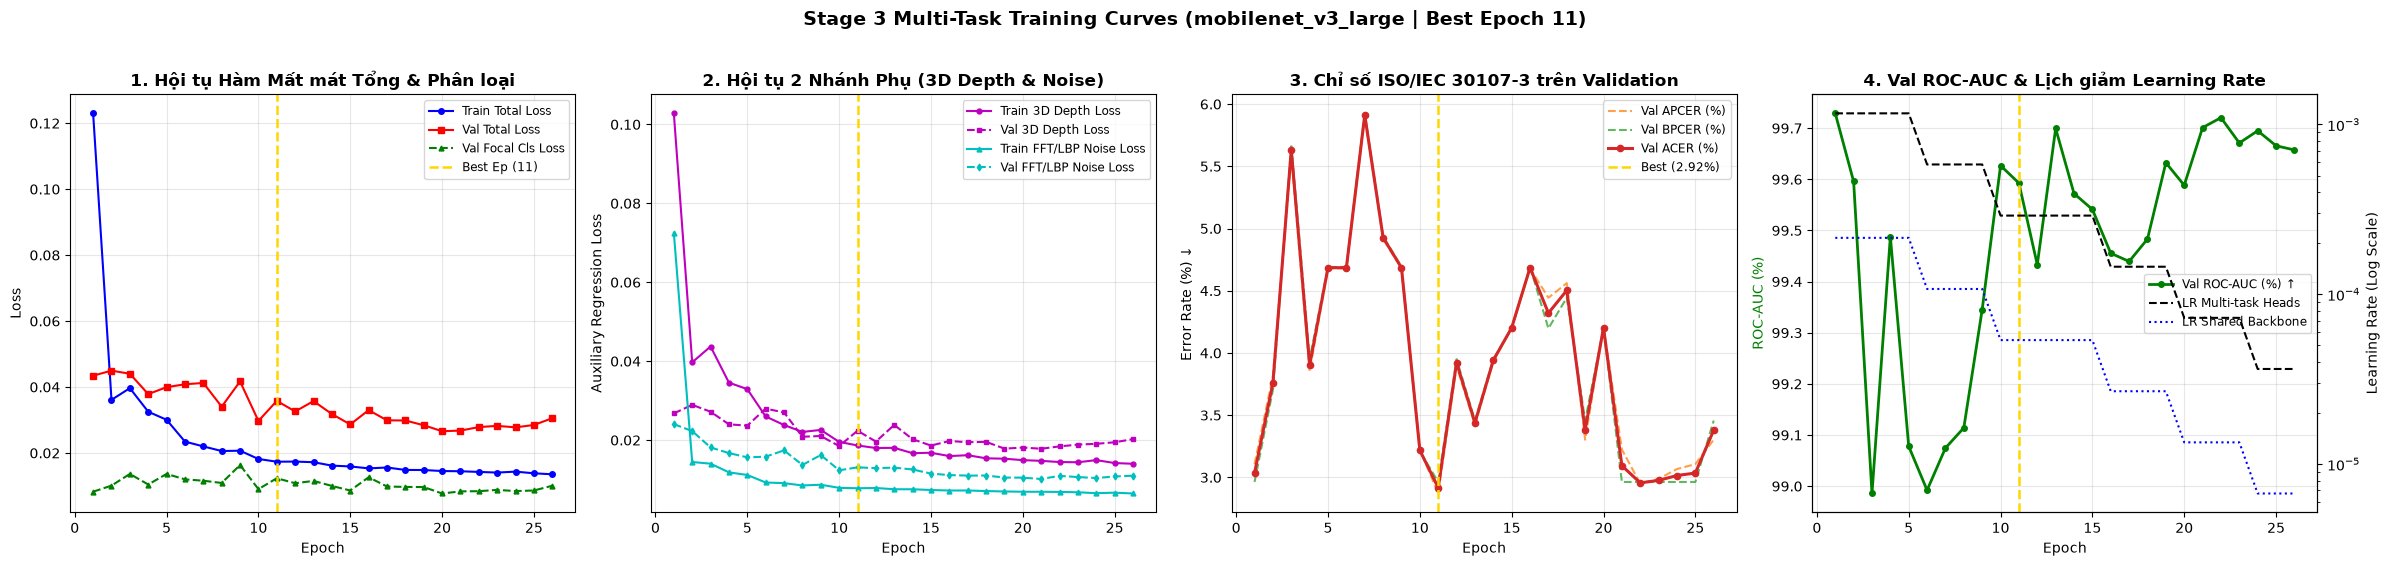

💾 Đã lưu biểu đồ quá trình huấn luyện tại: /home/dainguyen1506/Documents/face-anti-spoofing/checkpoint/stage3/training_curves_stage3.png


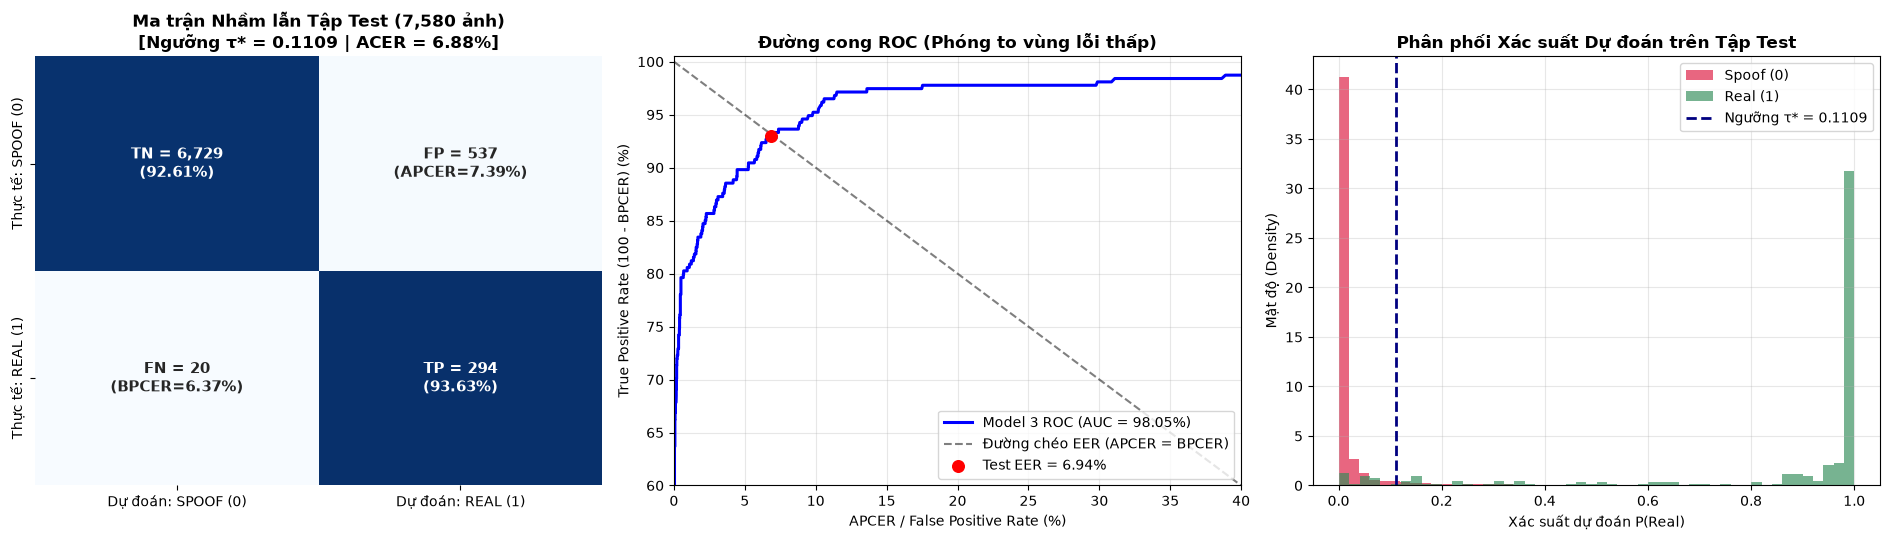

💾 Đã lưu biểu đồ chẩn đoán tập Test tại: /home/dainguyen1506/Documents/face-anti-spoofing/checkpoint/stage3/test_diagnostics_stage3.png


In [18]:
# === CELL 15: TRỰC QUAN HÓA QUÁ TRÌNH HỘI TỤ ĐA NHIỆM & CHẨN ĐOÁN TẬP TEST ===
TRAINING_CURVES_PNG  = ARTIFACTS_DIR / "training_curves_stage3.png"
TEST_DIAGNOSTICS_PNG = ARTIFACTS_DIR / "test_diagnostics_stage3.png"

# --- 1. Vẽ Biểu đồ Quá trình Huấn luyện Đa nhiệm (4 Subplots) ---
if HISTORY_CSV_PATH.exists():
    hist_df = pd.read_csv(HISTORY_CSV_PATH)
    fig, axes = plt.subplots(1, 4, figsize=(24, 5.5))

    # (1) Tổng Loss & Classification Focal Loss
    axes[0].plot(hist_df["epoch"], hist_df["train_loss"], "b-o", markersize=4, label="Train Total Loss")
    axes[0].plot(hist_df["epoch"], hist_df["val_loss"],   "r-s", markersize=4, label="Val Total Loss")
    axes[0].plot(hist_df["epoch"], hist_df["val_cls_loss"], "g--^", markersize=3.5, label="Val Focal Cls Loss")
    axes[0].axvline(best_epoch3, color="gold", linestyle="--", linewidth=1.8, label=f"Best Ep ({best_epoch3})")
    axes[0].set_title("1. Hội tụ Hàm Mất mát Tổng & Phân loại", fontweight="bold")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend(fontsize=8.5)

    # (2) Hai Nhánh Giám sát Phụ: 3D Depth Loss & FFT/LBP Noise Loss
    axes[1].plot(hist_df["epoch"], hist_df["train_depth_loss"], "m-o", markersize=3.5, label="Train 3D Depth Loss")
    axes[1].plot(hist_df["epoch"], hist_df["val_depth_loss"],   "m--s", markersize=3.5, label="Val 3D Depth Loss")
    axes[1].plot(hist_df["epoch"], hist_df["train_noise_loss"], "c-^", markersize=3.5, label="Train FFT/LBP Noise Loss")
    axes[1].plot(hist_df["epoch"], hist_df["val_noise_loss"],   "c--d", markersize=3.5, label="Val FFT/LBP Noise Loss")
    axes[1].axvline(best_epoch3, color="gold", linestyle="--", linewidth=1.8)
    axes[1].set_title("2. Hội tụ 2 Nhánh Phụ (3D Depth & Noise)", fontweight="bold")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Auxiliary Regression Loss")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend(fontsize=8.5)

    # (3) Các tỷ lệ lỗi ISO/IEC 30107-3 trên tập Validation
    axes[2].plot(hist_df["epoch"], hist_df["val_APCER"], "C1--", alpha=0.75, label="Val APCER (%)")
    axes[2].plot(hist_df["epoch"], hist_df["val_BPCER"], "C2--", alpha=0.75, label="Val BPCER (%)")
    axes[2].plot(hist_df["epoch"], hist_df["val_ACER"],  "C3-o", linewidth=2.2, markersize=4.5, label="Val ACER (%)")
    axes[2].axvline(best_epoch3, color="gold", linestyle="--", linewidth=1.8, label=f"Best ({val_final3['ACER']:.2f}%)")
    axes[2].set_title("3. Chỉ số ISO/IEC 30107-3 trên Validation", fontweight="bold")
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("Error Rate (%) ↓")
    axes[2].grid(True, alpha=0.3)
    axes[2].legend(fontsize=8.5)

    # (4) ROC-AUC & Bậc thang Giảm Learning Rate
    ax4_twin = axes[3].twinx()
    l1 = axes[3].plot(hist_df["epoch"], hist_df["val_AUC"], "g-o", linewidth=2.0, markersize=4, label="Val ROC-AUC (%) ↑")
    l2 = ax4_twin.plot(hist_df["epoch"], hist_df["lr_head"], "k--", linewidth=1.5, label="LR Multi-task Heads")
    l3 = ax4_twin.plot(hist_df["epoch"], hist_df["lr_backbone"], "b:", linewidth=1.5, label="LR Shared Backbone")
    axes[3].axvline(best_epoch3, color="gold", linestyle="--", linewidth=1.8)
    axes[3].set_title("4. Val ROC-AUC & Lịch giảm Learning Rate", fontweight="bold")
    axes[3].set_xlabel("Epoch")
    axes[3].set_ylabel("ROC-AUC (%)", color="g")
    ax4_twin.set_ylabel("Learning Rate (Log Scale)", color="k")
    ax4_twin.set_yscale("log")
    axes[3].grid(True, alpha=0.3)
    lines = l1 + l2 + l3
    labels_l = [l.get_label() for l in lines]
    axes[3].legend(lines, labels_l, loc="center right", fontsize=8.5)

    plt.suptitle(f"Stage 3 Multi-Task Training Curves ({model_cfg3['backbone_name']} | Best Epoch {best_epoch3})", fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig(TRAINING_CURVES_PNG, dpi=180, bbox_inches="tight")
    plt.show()
    print(f"💾 Đã lưu biểu đồ quá trình huấn luyện tại: {TRAINING_CURVES_PNG}")

# --- 2. Vẽ Biểu đồ Chẩn đoán Tập Test (Confusion Matrix, ROC Curve, Score Distribution) ---
y_true_t = test_fixed3["y_true"]
y_prob_t = test_fixed3["y_prob"]
y_pred_t = (y_prob_t >= val_threshold3).astype(np.int64)

fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))

# (A) Ma trận nhầm lẫn (Confusion Matrix)
cm = confusion_matrix(y_true_t, y_pred_t, labels=[0, 1])
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100.0
annot_matrix = np.array([
    [f"TN = {cm[0,0]:,d}\n({cm_pct[0,0]:.2f}%)", f"FP = {cm[0,1]:,d}\n(APCER={cm_pct[0,1]:.2f}%)"],
    [f"FN = {cm[1,0]:,d}\n(BPCER={cm_pct[1,0]:.2f}%)", f"TP = {cm[1,1]:,d}\n({cm_pct[1,1]:.2f}%)"]
])
sns.heatmap(cm_pct, annot=annot_matrix, fmt="", cmap="Blues", cbar=False, ax=axes[0],
            xticklabels=["Dự đoán: SPOOF (0)", "Dự đoán: REAL (1)"],
            yticklabels=["Thực tế: SPOOF (0)", "Thực tế: REAL (1)"],
            annot_kws={"size": 11, "weight": "bold"})
axes[0].set_title(f"Ma trận Nhầm lẫn Tập Test (7,580 ảnh)\n[Ngưỡng τ* = {val_threshold3:.4f} | ACER = {test_fixed3['ACER']:.2f}%]", fontweight="bold")

# (B) Đường cong ROC & Điểm EER
fpr_t, tpr_t, _ = roc_curve(y_true_t, y_prob_t, pos_label=1)
axes[1].plot(fpr_t * 100.0, tpr_t * 100.0, "b-", linewidth=2.2, label=f"Model 3 ROC (AUC = {test_fixed3['AUC']:.2f}%)")
axes[1].plot([0, 100], [100, 0], "k--", alpha=0.5, label="Đường chéo EER (APCER = BPCER)")
axes[1].scatter([test_eer3["APCER"]], [100.0 - test_eer3["BPCER"]], color="red", s=70, zorder=5,
                label=f"Test EER = {test_eer3['EER']:.2f}%")
axes[1].set_xlim([0.0, 40.0])
axes[1].set_ylim([60.0, 100.5])
axes[1].set_xlabel("APCER / False Positive Rate (%)")
axes[1].set_ylabel("True Positive Rate (100 - BPCER) (%)")
axes[1].set_title("Đường cong ROC (Phóng to vùng lỗi thấp)", fontweight="bold")
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc="lower right")

# (C) Phân phối xác suất P(Real) giữa lớp Spoof và lớp Real
axes[2].hist(y_prob_t[y_true_t == 0], bins=50, alpha=0.65, color="crimson", label="Spoof (0)", density=True)
axes[2].hist(y_prob_t[y_true_t == 1], bins=50, alpha=0.65, color="seagreen", label="Real (1)", density=True)
axes[2].axvline(val_threshold3, color="navy", linestyle="--", linewidth=2.0, label=f"Ngưỡng τ* = {val_threshold3:.4f}")
axes[2].set_xlabel("Xác suất dự đoán P(Real)")
axes[2].set_ylabel("Mật độ (Density)")
axes[2].set_title("Phân phối Xác suất Dự đoán trên Tập Test", fontweight="bold")
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.savefig(TEST_DIAGNOSTICS_PNG, dpi=180, bbox_inches="tight")
plt.show()
print(f"💾 Đã lưu biểu đồ chẩn đoán tập Test tại: {TEST_DIAGNOSTICS_PNG}")

### Trực quan hóa Bản đồ 3D Depth & Noise Dự đoán trên Tập Test + Đo Tốc độ Live Camera Inference

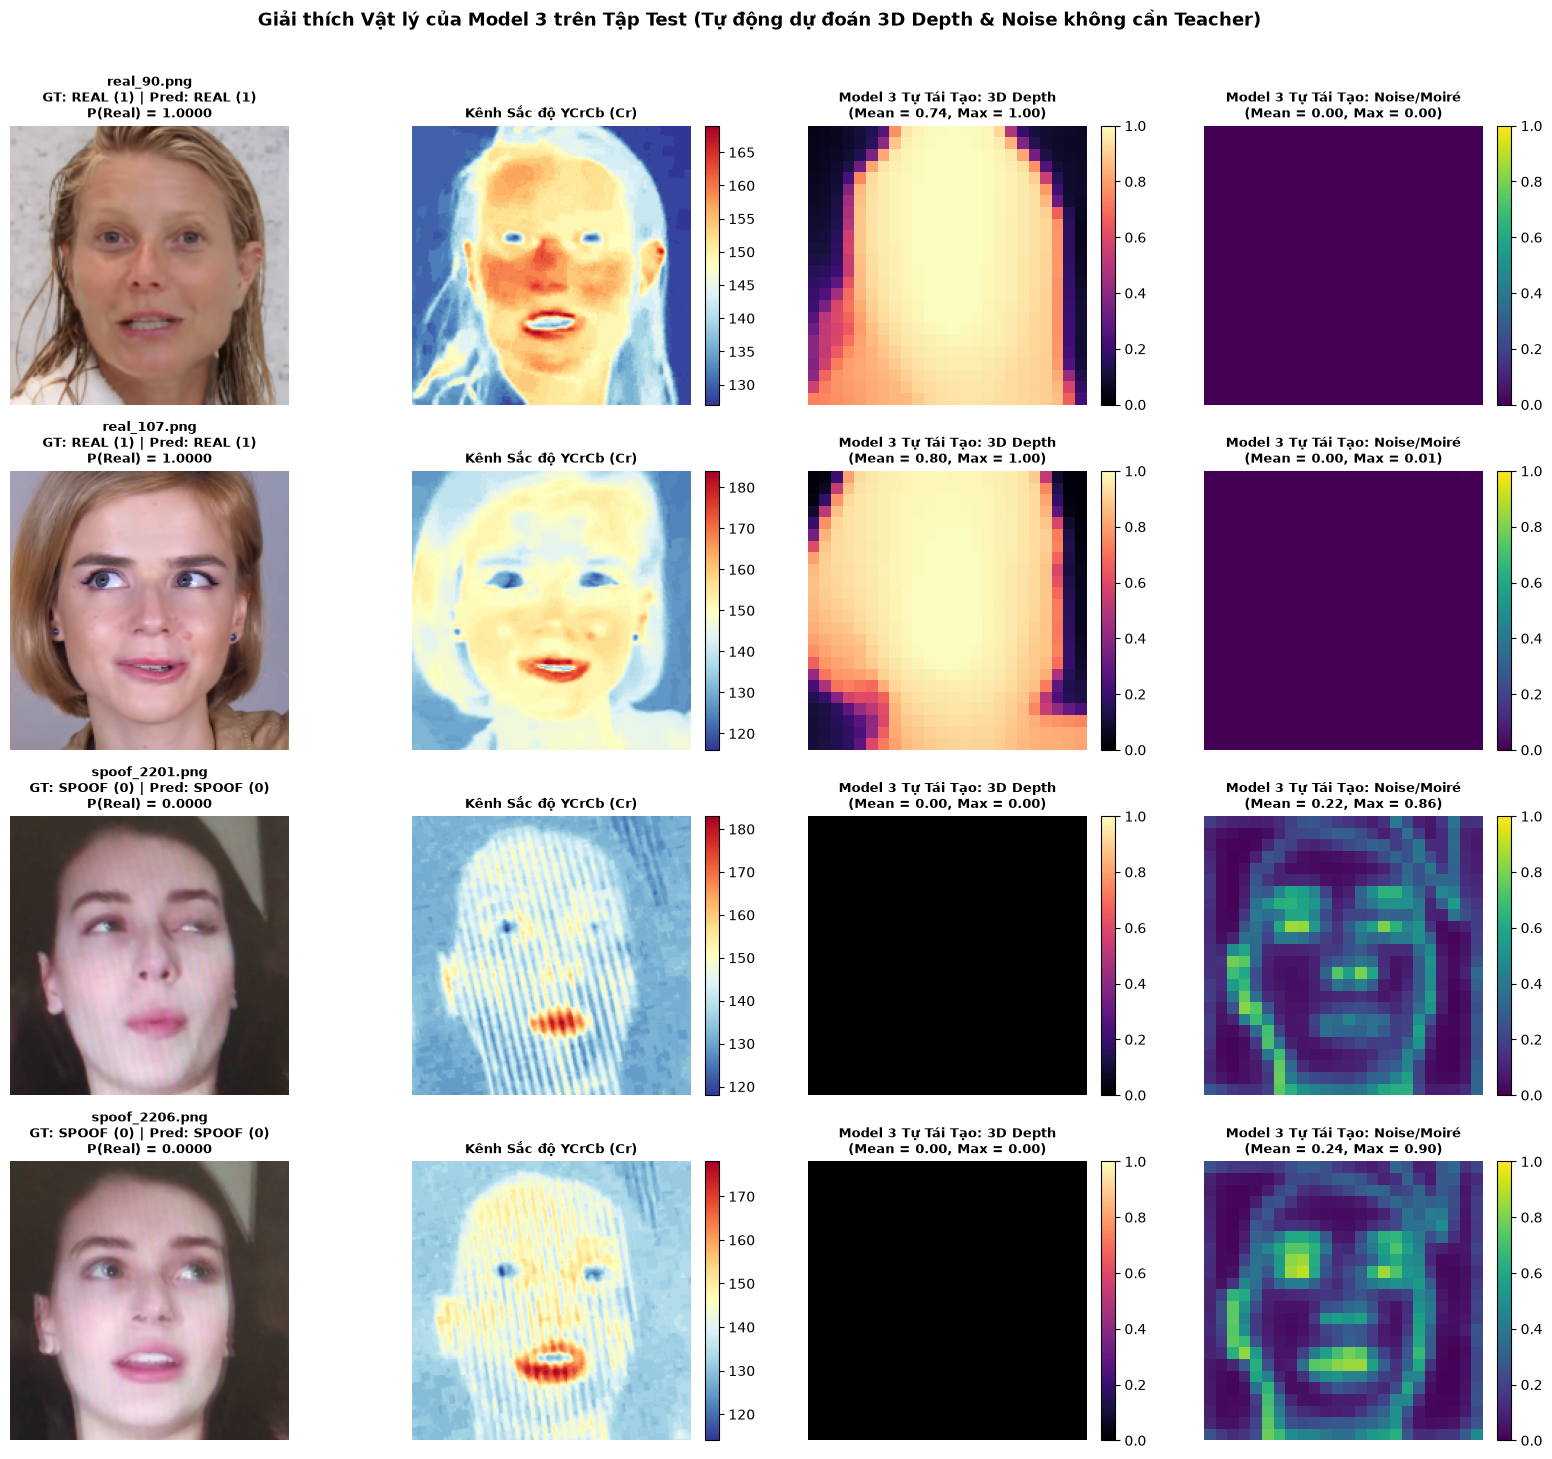

💾 Đã lưu hình trực quan hóa đa nhiệm tại: /home/dainguyen1506/Documents/face-anti-spoofing/checkpoint/stage3/multitask_predictions_stage3.png


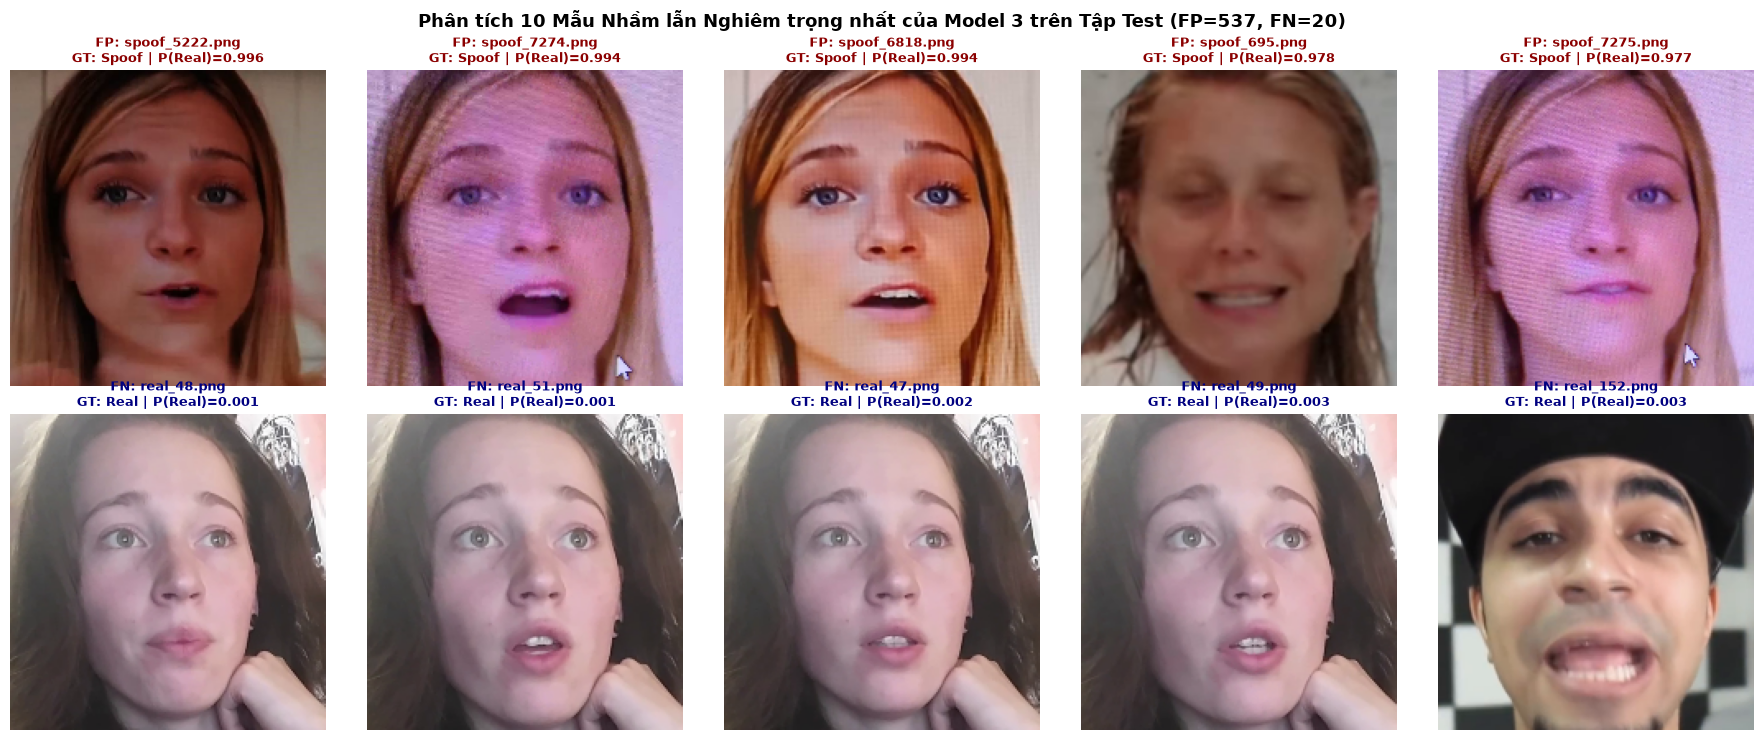

💾 Đã lưu biểu đồ phân tích lỗi tại: /home/dainguyen1506/Documents/face-anti-spoofing/checkpoint/stage3/error_analysis_stage3.png

⚡ TỐC ĐỘ SUY LUẬN REAL-TIME CỦA MODEL 3 TRÊN xpu:0: 19.14 ms/frame (~52.3 FPS)
📦 File mô hình duy nhất dùng để Deploy Live Camera : /home/dainguyen1506/Documents/face-anti-spoofing/models/model3_multitask_best.pt


In [ ]:
# === CELL 16: TRỰC QUAN HÓA BẢN ĐỒ 3D DEPTH & NOISE DỰ ĐOÁN CỦA MODEL 3 TRÊN TẬP TEST + BENCHMARK LIVE ===
MULTITASK_VIS_PNG  = ARTIFACTS_DIR / "multitask_predictions_stage3.png"
ERROR_ANALYSIS_PNG = ARTIFACTS_DIR / "error_analysis_stage3.png"

# --- 1. Trực quan hóa Bản đồ 3D Depth & Noise do chính Model 3 tự tái tạo trên các mẫu Test ---
y_true_t = test_fixed3["y_true"]
y_prob_t = test_fixed3["y_prob"]

# Chọn 2 mẫu Real dự đoán đúng tự tin nhất và 2 mẫu Spoof dự đoán đúng tự tin nhất trên tập Test
tp_indices = np.where((y_true_t == 1) & (y_prob_t >= val_threshold3))[0]
tn_indices = np.where((y_true_t == 0) & (y_prob_t <  val_threshold3))[0]

top_real_idx  = tp_indices[np.argsort(-y_prob_t[tp_indices])[:2]] if len(tp_indices) >= 2 else [0, 1]
top_spoof_idx = tn_indices[np.argsort(y_prob_t[tn_indices])[:2]]  if len(tn_indices) >= 2 else [2, 3]
demo_indices  = list(top_real_idx) + list(top_spoof_idx)

fig, axes = plt.subplots(len(demo_indices), 4, figsize=(16, 3.6 * len(demo_indices)))
eval_model3.eval()

with torch.no_grad():
    for row_i, ds_idx in enumerate(demo_indices):
        img_t, lbl_t, _, _ = test_ds[int(ds_idx)]
        img_dev = img_t.unsqueeze(0).to(DEVICE)
        if USE_CHANNELS_LAST:
            img_dev = img_dev.to(memory_format=torch.channels_last)

        with torch.amp.autocast(device_type=AUTOCAST_DEVICE_TYPE, dtype=AUTOCAST_DTYPE, enabled=USE_AMP):
            logits_d, pred_d_map, pred_n_map = eval_model3(img_dev, return_maps=True)
            prob_r = float(F.softmax(logits_d.float(), dim=-1)[0, 1].item())

        # Khôi phục ảnh RGB để hiển thị
        rgb_vis = img_t.permute(1, 2, 0).numpy()
        rgb_vis = np.clip(rgb_vis * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN), 0.0, 1.0)
        ycrcb_cr = cv2.cvtColor((rgb_vis * 255.0).astype(np.uint8), cv2.COLOR_RGB2YCrCb)[:, :, 1]

        d_map_np = pred_d_map[0, 0].float().cpu().numpy()
        n_map_np = pred_n_map[0, 0].float().cpu().numpy()

        true_str = "REAL (1)" if int(lbl_t) == 1 else "SPOOF (0)"
        pred_str = "REAL (1)" if prob_r >= val_threshold3 else "SPOOF (0)"
        fname    = Path(test_samples[int(ds_idx)][0]).name

        axes[row_i, 0].imshow(rgb_vis)
        axes[row_i, 0].set_title(f"{fname}\nGT: {true_str} | Pred: {pred_str}\nP(Real) = {prob_r:.4f}", fontweight="bold", fontsize=9.5)
        axes[row_i, 0].axis("off")

        im_cr = axes[row_i, 1].imshow(ycrcb_cr, cmap="RdYlBu_r")
        axes[row_i, 1].set_title("Kênh Sắc độ YCrCb (Cr)", fontweight="bold", fontsize=9.5)
        axes[row_i, 1].axis("off")
        plt.colorbar(im_cr, ax=axes[row_i, 1], fraction=0.046, pad=0.04)

        im_d = axes[row_i, 2].imshow(d_map_np, cmap="magma", vmin=0.0, vmax=1.0)
        axes[row_i, 2].set_title(f"Model 3 Tự Tái Tạo: 3D Depth\n(Mean = {d_map_np.mean():.2f}, Max = {d_map_np.max():.2f})", fontweight="bold", fontsize=9.5)
        axes[row_i, 2].axis("off")
        plt.colorbar(im_d, ax=axes[row_i, 2], fraction=0.046, pad=0.04)

        im_n = axes[row_i, 3].imshow(n_map_np, cmap="viridis", vmin=0.0, vmax=1.0)
        axes[row_i, 3].set_title(f"Model 3 Tự Tái Tạo: Noise/Moiré\n(Mean = {n_map_np.mean():.2f}, Max = {n_map_np.max():.2f})", fontweight="bold", fontsize=9.5)
        axes[row_i, 3].axis("off")
        plt.colorbar(im_n, ax=axes[row_i, 3], fraction=0.046, pad=0.04)

plt.suptitle("Giải thích Vật lý của Model 3 trên Tập Test (Tự động dự đoán 3D Depth & Noise không cần Teacher)", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(MULTITASK_VIS_PNG, dpi=180, bbox_inches="tight")
plt.show()
print(f"💾 Đã lưu hình trực quan hóa đa nhiệm tại: {MULTITASK_VIS_PNG}")

# --- 2. Phân tích 10 Ca Lỗi Nặng Nhất trên Tập Test (5 False Positives + 5 False Negatives) ---
fp_idx = np.where((y_true_t == 0) & (y_prob_t >= val_threshold3))[0]
fn_idx = np.where((y_true_t == 1) & (y_prob_t <  val_threshold3))[0]

worst_fp = fp_idx[np.argsort(-y_prob_t[fp_idx])[:5]]
worst_fn = fn_idx[np.argsort(y_prob_t[fn_idx])[:5]]

fig, axes = plt.subplots(2, 5, figsize=(18, 7.5))
for col_i in range(5):
    # Hàng 1: False Positives (Spoof bị nhầm thành Real)
    ax_fp = axes[0, col_i]
    if col_i < len(worst_fp):
        idx_i = int(worst_fp[col_i])
        img_rgb = cv2.cvtColor(cv2.imread(test_samples[idx_i][0]), cv2.COLOR_BGR2RGB)
        ax_fp.imshow(cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE)))
        ax_fp.set_title(f"FP: {Path(test_samples[idx_i][0]).name}\nGT: Spoof | P(Real)={y_prob_t[idx_i]:.3f}", color="darkred", fontweight="bold", fontsize=9)
    ax_fp.axis("off")

    # Hàng 2: False Negatives (Real bị từ chối nhầm thành Spoof)
    ax_fn = axes[1, col_i]
    if col_i < len(worst_fn):
        idx_i = int(worst_fn[col_i])
        img_rgb = cv2.cvtColor(cv2.imread(test_samples[idx_i][0]), cv2.COLOR_BGR2RGB)
        ax_fn.imshow(cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE)))
        ax_fn.set_title(f"FN: {Path(test_samples[idx_i][0]).name}\nGT: Real | P(Real)={y_prob_t[idx_i]:.3f}", color="navy", fontweight="bold", fontsize=9)
    ax_fn.axis("off")

plt.suptitle(f"Phân tích 10 Mẫu Nhầm lẫn Nghiêm trọng nhất của Model 3 trên Tập Test (FP={len(fp_idx)}, FN={len(fn_idx)})", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(ERROR_ANALYSIS_PNG, dpi=180, bbox_inches="tight")
plt.show()
print(f"💾 Đã lưu biểu đồ phân tích lỗi tại: {ERROR_ANALYSIS_PNG}")

# --- 3. Đo tốc độ suy luận thực tế (Real-time Live Camera Benchmark trên XPU) ---
dummy_frame = torch.randn(1, 3, IMG_SIZE, IMG_SIZE, device=DEVICE)
if USE_CHANNELS_LAST:
    dummy_frame = dummy_frame.to(memory_format=torch.channels_last)

with torch.no_grad():
    for _ in range(10):  # Warm-up XPU
        with torch.amp.autocast(device_type=AUTOCAST_DEVICE_TYPE, dtype=AUTOCAST_DTYPE, enabled=USE_AMP):
            _ = eval_model3(dummy_frame, return_maps=False)
    if has_xpu:
        torch.xpu.synchronize()

    t_bench = time.time()
    n_runs = 100
    for _ in range(n_runs):
        with torch.amp.autocast(device_type=AUTOCAST_DEVICE_TYPE, dtype=AUTOCAST_DTYPE, enabled=USE_AMP):
            _ = eval_model3(dummy_frame, return_maps=False)
    if has_xpu:
        torch.xpu.synchronize()
    avg_ms = (time.time() - t_bench) / n_runs * 1000.0

print("\n" + "="*95)
print(f"⚡ TỐC ĐỘ SUY LUẬN REAL-TIME CỦA MODEL 3 TRÊN {DEVICE}: {avg_ms:.2f} ms/frame (~{1000.0/avg_ms:.1f} FPS)")
print(f"📦 File mô hình duy nhất dùng để Deploy Live Camera : {MODEL3_BEST_CKPT_PATH}")
print("="*95)